# Iris Recognition Based on Mathematical Modeling and Image Processing Techniques

## Get acceses from drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


##Exploring dataset structure

In [2]:
import os
!apt-get install unrar

!unrar x "/content/drive/MyDrive/CASIA-Iris-Thousand.rar" "/content/CASIA-Iris-Thousand/"



Streaming output truncated to the last 5000 lines.
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/782/R/S5782R04.jpg      78%  OK 
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/782/R/S5782R05.jpg      78%  OK 
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/782/R/S5782R06.jpg      78%  OK 
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/782/R/S5782R07.jpg      78%  OK 
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/782/R/S5782R08.jpg      78%  OK 
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/782/R/S5782R09.jpg      78%  OK 
Creating    /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/783      OK
Creating    /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/783/L    OK
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/783/L/S5783L00.jpg      78%  OK 
Extracting  /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/783/L/S5783L01.jpg   

In [3]:
DATASET_ROOT = "/content/CASIA-Iris-Thousand"



## 1: IRIS SEGMENTATION
Detects pupil and iris boundaries using Hough Transform with concentric circles.



PHASE 1: IRIS SEGMENTATION

Loading image: /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/967/L/S5967L01.jpg
✓ Image loaded: 640x480 pixels

Step 1: Detecting pupil...
  ✓ Pupil detected: center=(344, 252), radius=28 px

Step 2: Detecting iris boundary...
  ✓ Iris detected: center=(344, 252), radius=100 px
  ✓ Circles are CONCENTRIC (same center)
  ✓ Iris/Pupil ratio: 3.57

Generating visualizations...
📊 Visualization saved: outputs/segmentation/segmentation_result.png


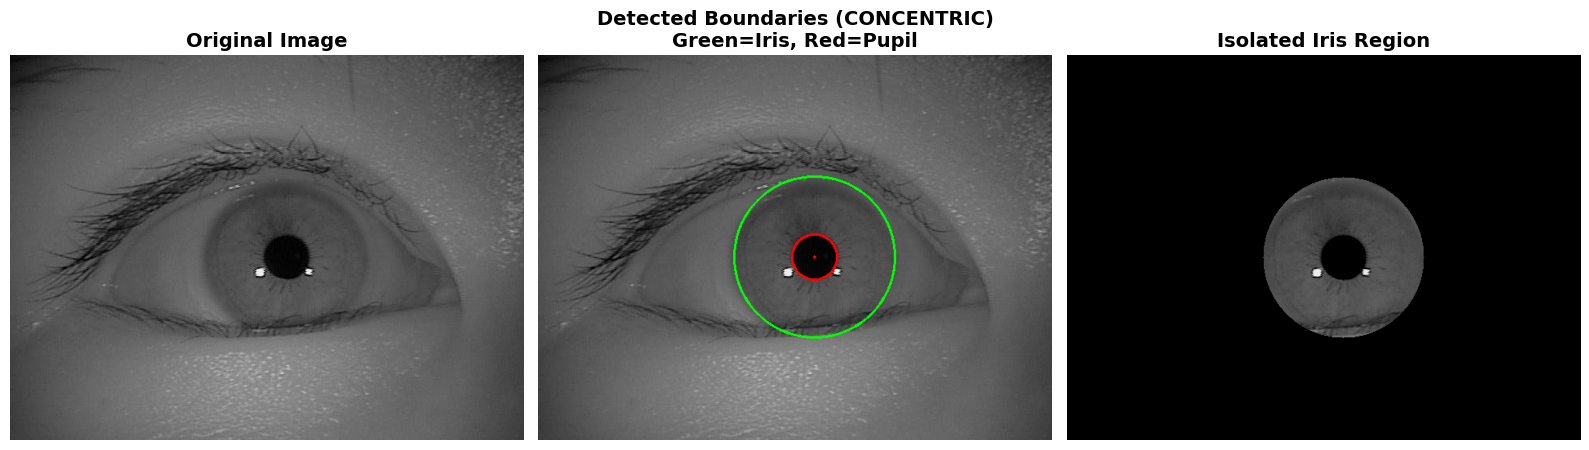

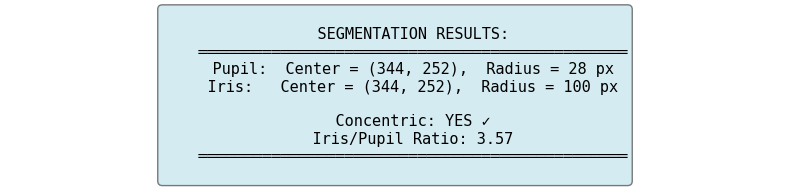


💾 Parameters saved: outputs/segmentation/segmentation_params.json
💾 Isolated iris saved: outputs/segmentation/isolated_iris.png

✓✓✓ PHASE 1 COMPLETE! ✓✓✓

📁 All outputs saved to: outputs/segmentation


In [4]:


import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json


def detect_pupil_hough(image, visualize=False):
    """
    Detect pupil using Hough Circle Transform.
    Pupil is the darkest circular region.

    Parameters:
        image: Grayscale image
        visualize: Whether to show detection visualization

    Returns:
        tuple: (center_x, center_y, radius)
    """
    # Ensure uint8
    if image.dtype != np.uint8:
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Preprocessing
    blurred = cv2.GaussianBlur(image, (9, 9), 2)

    # Detect circles
    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=50,
        param1=50,
        param2=20,
        minRadius=20,
        maxRadius=90
    )

    if circles is None:
        print("⚠️  No pupil detected, using fallback center position")
        h, w = image.shape
        return (w//2, h//2, 30)

    # Take the darkest circle (most likely the pupil)
    circles = np.uint16(np.around(circles))
    best_circle = None
    min_intensity = 255

    for circle in circles[0, :]:
        cx, cy, r = circle
        mask = np.zeros_like(image)
        cv2.circle(mask, (cx, cy), r, 255, -1)
        mean_intensity = cv2.mean(image, mask=mask)[0]

        if mean_intensity < min_intensity:
            min_intensity = mean_intensity
            best_circle = (cx, cy, r)

    if visualize and best_circle is not None:
        vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        px, py, pr = best_circle
        cv2.circle(vis, (px, py), pr, (0, 0, 255), 2)
        cv2.circle(vis, (px, py), 2, (0, 0, 255), -1)

        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title('Pupil Detection (Hough Transform)', fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return best_circle


def detect_iris_radius(image, pupil_x, pupil_y, pupil_r):
    """
    Find optimal iris radius with center fixed at pupil center.
    Uses radial gradient analysis to find the iris boundary.

    Parameters:
        image: Grayscale image
        pupil_x, pupil_y: Pupil center coordinates
        pupil_r: Pupil radius

    Returns:
        int: Iris radius
    """
    # Preprocess for better edge detection
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(image)
    smoothed = cv2.bilateralFilter(enhanced, 9, 75, 75)
    blurred = cv2.medianBlur(smoothed, 5)

    # Search range for iris radius
    min_radius = int(pupil_r * 2.0)
    max_radius = int(pupil_r * 4.5)

    best_radius = min_radius
    max_gradient = 0

    h, w = blurred.shape

    for r in range(min_radius, max_radius, 2):
        num_points = max(int(2 * np.pi * r), 32)
        theta = np.linspace(0, 2*np.pi, num_points, endpoint=False)

        x_coords = pupil_x + r * np.cos(theta)
        y_coords = pupil_y + r * np.sin(theta)

        valid = (x_coords >= 1) & (x_coords < w-1) & (y_coords >= 1) & (y_coords < h-1)

        if not np.any(valid):
            continue

        x_coords = x_coords[valid]
        y_coords = y_coords[valid]

        inner_r = max(1, r - 3)
        outer_r = min(min(h, w)//2, r + 3)

        x_inner = pupil_x + inner_r * np.cos(theta[valid])
        y_inner = pupil_y + inner_r * np.sin(theta[valid])
        x_outer = pupil_x + outer_r * np.cos(theta[valid])
        y_outer = pupil_y + outer_r * np.sin(theta[valid])

        x_int = np.clip(x_coords.astype(int), 0, w-1)
        y_int = np.clip(y_coords.astype(int), 0, h-1)
        x_inner_int = np.clip(x_inner.astype(int), 0, w-1)
        y_inner_int = np.clip(y_inner.astype(int), 0, h-1)
        x_outer_int = np.clip(x_outer.astype(int), 0, w-1)
        y_outer_int = np.clip(y_outer.astype(int), 0, h-1)

        inner_values = blurred[y_inner_int, x_inner_int]
        outer_values = blurred[y_outer_int, x_outer_int]

        gradient = np.abs(outer_values.astype(float) - inner_values.astype(float))
        avg_gradient = np.mean(gradient)

        if avg_gradient > max_gradient:
            max_gradient = avg_gradient
            best_radius = r

    return best_radius


def visualize_segmentation(image, pupil_params, iris_params, output_path=None):
    """
    Visualize segmentation results.

    Parameters:
        image: Original grayscale image
        pupil_params: (x, y, r) for pupil
        iris_params: (x, y, r) for iris
        output_path: Optional path to save visualization
    """
    px, py, pr = pupil_params
    ix, iy, ir = iris_params

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Original Image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # 2. Detection overlay
    result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    cv2.circle(result, (ix, iy), ir, (0, 255, 0), 2)
    cv2.circle(result, (ix, iy), 2, (0, 255, 0), -1)
    cv2.circle(result, (px, py), pr, (0, 0, 255), 2)
    cv2.circle(result, (px, py), 2, (0, 0, 255), -1)

    title = 'Detected Boundaries (CONCENTRIC)\nGreen=Iris, Red=Pupil'
    axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[1].set_title(title, fontsize=14, fontweight='bold')
    axes[1].axis('off')

    # 3. Isolated iris
    mask = np.zeros_like(image)
    cv2.circle(mask, (ix, iy), ir, 255, -1)
    cv2.circle(mask, (px, py), pr, 0, -1)
    isolated = cv2.bitwise_and(image, image, mask=mask)

    axes[2].imshow(isolated, cmap='gray')
    axes[2].set_title('Isolated Iris Region', fontsize=14, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"📊 Visualization saved: {output_path}")

    plt.show()

    # Info plot
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.axis('off')

    info_text = f"""
    SEGMENTATION RESULTS:
    ═══════════════════════════════════════════════
    Pupil:  Center = ({px}, {py}),  Radius = {pr} px
    Iris:   Center = ({ix}, {iy}),  Radius = {ir} px

    Concentric: {'YES ✓' if (px == ix and py == iy) else 'NO ✗'}
    Iris/Pupil Ratio: {ir/pr:.2f}
    ═══════════════════════════════════════════════
    """

    ax.text(0.5, 0.5, info_text, ha='center', va='center',
            fontsize=11, family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    plt.tight_layout()
    plt.show()


def segment_iris(image_path, output_dir='CASIA-Iris-Thousand/outputs/segmentation', visualize=True):
    """
    Main function for iris segmentation.

    Parameters:
        image_path: Path to input iris image
        output_dir: Directory to save outputs
        visualize: Whether to show visualizations

    Returns:
        dict: Segmentation results
    """
    print("\n" + "=" * 70)
    print("PHASE 1: IRIS SEGMENTATION")
    print("=" * 70)

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Load image
    print(f"\nLoading image: {image_path}")
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"❌ Could not load image from {image_path}")

    print(f"✓ Image loaded: {image.shape[1]}x{image.shape[0]} pixels")

    # Step 1: Detect pupil
    print("\nStep 1: Detecting pupil...")
    pupil_params = detect_pupil_hough(image, visualize=False)
    px, py, pr = pupil_params
    print(f"  ✓ Pupil detected: center=({px}, {py}), radius={pr} px")

    # Step 2: Detect iris
    print("\nStep 2: Detecting iris boundary...")
    iris_r = detect_iris_radius(image, px, py, pr)
    iris_params = (px, py, iris_r)
    print(f"  ✓ Iris detected: center=({px}, {py}), radius={iris_r} px")
    print(f"  ✓ Circles are CONCENTRIC (same center)")
    print(f"  ✓ Iris/Pupil ratio: {iris_r/pr:.2f}")

    # Visualize
    if visualize:
        print("\nGenerating visualizations...")
        viz_path = os.path.join(output_dir, 'segmentation_result.png')
        visualize_segmentation(image, pupil_params, iris_params, viz_path)

    # Save parameters
    params = {
        'image_path': image_path,
        'pupil': {'center': [int(px), int(py)], 'radius': int(pr)},
        'iris': {'center': [int(px), int(py)], 'radius': int(iris_r)},
        'concentric': True,
        'ratio': float(iris_r / pr)
    }

    params_path = os.path.join(output_dir, 'segmentation_params.json')
    with open(params_path, 'w') as f:
        json.dump(params, f, indent=2)
    print(f"\n💾 Parameters saved: {params_path}")

    # Save isolated iris image
    mask = np.zeros_like(image)
    cv2.circle(mask, (px, py), iris_r, 255, -1)
    cv2.circle(mask, (px, py), pr, 0, -1)
    isolated = cv2.bitwise_and(image, image, mask=mask)

    isolated_path = os.path.join(output_dir, 'isolated_iris.png')
    cv2.imwrite(isolated_path, isolated)
    print(f"💾 Isolated iris saved: {isolated_path}")

    results = {
        'image': image,
        'pupil_params': pupil_params,
        'iris_params': iris_params,
        'params': params,
        'output_dir': output_dir
    }

    print("\n" + "=" * 70)
    print("✓✓✓ PHASE 1 COMPLETE! ✓✓✓")
    print("=" * 70)

    return results


if __name__ == "__main__":
    # CONFIGURATION: Set your image path here
    IMAGE_PATH = "/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/967/L/S5967L01.jpg"  # ← CHANGE THIS

    # Run segmentation
    results = segment_iris(
        image_path=IMAGE_PATH,
        output_dir='outputs/segmentation',
        visualize=True
    )

    print(f"\n📁 All outputs saved to: {results['output_dir']}")

## 2: Normalization
Unwraps the iris region using Daugman's Rubber Sheet Model


PHASE 2: IRIS NORMALIZATION

Loading segmentation parameters from: outputs/segmentation/segmentation_params.json
✓ Parameters loaded

Loading original image: /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/967/L/S5967L01.jpg
✓ Image loaded: (480, 640)

Step 1: Normalizing iris using Rubber Sheet Model...
  ✓ Normalized iris shape: (64, 512)
  ✓ Valid pixels: 32768/32768 (100.0%)
  - Zero pixels: 0.0%
  - Mean intensity: 75.84
  - Std intensity: 17.66

Generating visualizations...
📊 Visualization saved: outputs/normalization/normalization_result.png


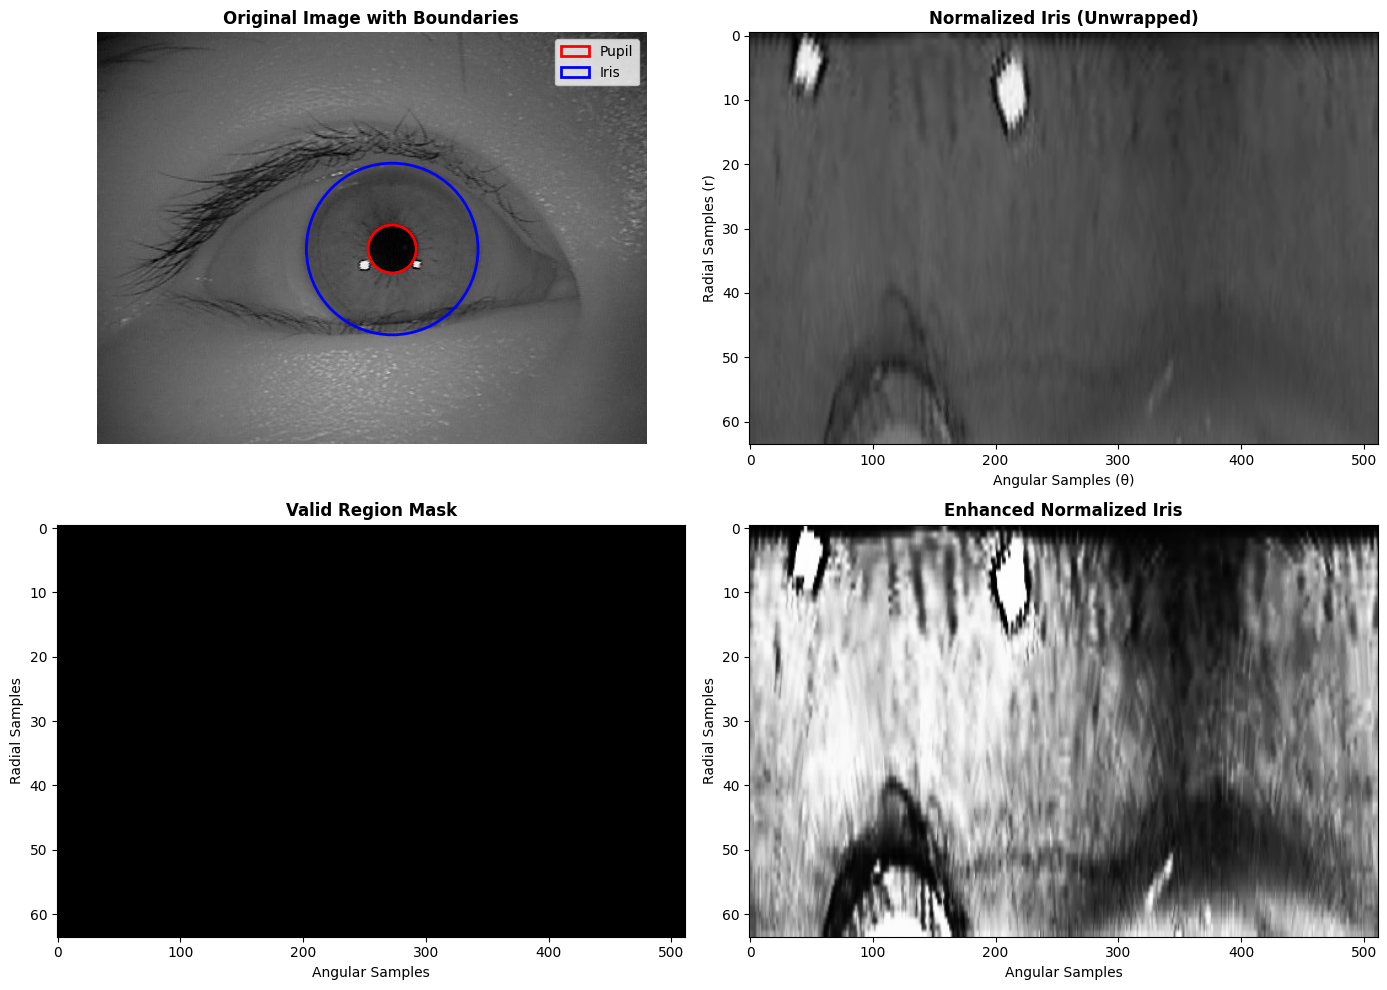


💾 Normalized iris saved: outputs/normalization/normalized_iris.png
💾 Noise mask saved: outputs/normalization/noise_mask.png
💾 Enhanced normalized saved: outputs/normalization/normalized_enhanced.png
💾 Normalization info saved: outputs/normalization/normalization_info.json

✓✓✓ PHASE 2 COMPLETE! ✓✓✓

📁 All outputs saved to: outputs/normalization


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json


def normalize_iris(image, pupil_center, pupil_radius, iris_center, iris_radius,
                   radial_res=64, angular_res=512):
    """
    Normalize iris using Daugman's Rubber Sheet Model.

    Unwraps the annular iris region into a rectangular block.

    Parameters:
        image: Grayscale image
        pupil_center: (x, y) coordinates of pupil center
        pupil_radius: Radius of pupil
        iris_center: (x, y) coordinates of iris center
        iris_radius: Radius of iris outer boundary
        radial_res: Number of radial samples (default: 64)
        angular_res: Number of angular samples (default: 512)

    Returns:
        normalized_iris: Normalized rectangular iris image (radial_res × angular_res)
        noise_mask: Binary mask indicating valid regions (1=valid, 0=invalid)
    """
    h, w = image.shape
    normalized_iris = np.zeros((radial_res, angular_res), dtype=np.uint8)
    noise_mask = np.ones((radial_res, angular_res), dtype=np.uint8)

    px, py = pupil_center
    ix, iy = iris_center

    for r in range(radial_res):
        for theta_idx in range(angular_res):
            # Normalized radius (0 = pupil boundary, 1 = iris boundary)
            r_norm = r / (radial_res - 1)

            # Angle in radians (0 to 2π)
            theta = (theta_idx / angular_res) * 2 * np.pi

            # Map to Cartesian coordinates
            x_pupil = px + pupil_radius * np.cos(theta)
            y_pupil = py + pupil_radius * np.sin(theta)

            x_iris = ix + iris_radius * np.cos(theta)
            y_iris = iy + iris_radius * np.sin(theta)

            # Interpolate between pupil and iris boundaries
            x = x_pupil + r_norm * (x_iris - x_pupil)
            y = y_pupil + r_norm * (y_iris - y_pupil)

            # Check bounds
            if 0 <= x < w-1 and 0 <= y < h-1:
                # Bilinear interpolation
                x_floor, y_floor = int(x), int(y)
                x_ceil, y_ceil = x_floor + 1, y_floor + 1

                dx = x - x_floor
                dy = y - y_floor

                val_00 = image[y_floor, x_floor]
                val_01 = image[y_floor, x_ceil]
                val_10 = image[y_ceil, x_floor]
                val_11 = image[y_ceil, x_ceil]

                interpolated_value = (
                    val_00 * (1 - dx) * (1 - dy) +
                    val_01 * dx * (1 - dy) +
                    val_10 * (1 - dx) * dy +
                    val_11 * dx * dy
                )

                normalized_iris[r, theta_idx] = int(interpolated_value)
            else:
                noise_mask[r, theta_idx] = 0

    return normalized_iris, noise_mask


def visualize_normalization(original, normalized, mask, pupil_params, iris_params, output_path=None):
    """
    Visualize normalization results.

    Parameters:
        original: Original grayscale image
        normalized: Normalized iris image
        mask: Noise mask
        pupil_params: (x, y, r) for pupil
        iris_params: (x, y, r) for iris
        output_path: Optional path to save visualization
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    px, py, pr = pupil_params
    ix, iy, ir = iris_params

    # 1. Original with boundaries
    axes[0, 0].imshow(original, cmap='gray')
    circle_pupil = plt.Circle((px, py), pr, color='red', fill=False, linewidth=2, label='Pupil')
    circle_iris = plt.Circle((ix, iy), ir, color='blue', fill=False, linewidth=2, label='Iris')
    axes[0, 0].add_patch(circle_pupil)
    axes[0, 0].add_patch(circle_iris)
    axes[0, 0].set_title('Original Image with Boundaries', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].axis('off')

    # 2. Normalized iris
    axes[0, 1].imshow(normalized, cmap='gray', aspect='auto')
    axes[0, 1].set_title('Normalized Iris (Unwrapped)', fontweight='bold')
    axes[0, 1].set_xlabel('Angular Samples (θ)')
    axes[0, 1].set_ylabel('Radial Samples (r)')

    # 3. Noise mask
    axes[1, 0].imshow(mask, cmap='gray', aspect='auto')
    axes[1, 0].set_title('Valid Region Mask', fontweight='bold')
    axes[1, 0].set_xlabel('Angular Samples')
    axes[1, 0].set_ylabel('Radial Samples')

    # 4. Enhanced normalized
    enhanced = cv2.equalizeHist(normalized)
    axes[1, 1].imshow(enhanced, cmap='gray', aspect='auto')
    axes[1, 1].set_title('Enhanced Normalized Iris', fontweight='bold')
    axes[1, 1].set_xlabel('Angular Samples')
    axes[1, 1].set_ylabel('Radial Samples')

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"📊 Visualization saved: {output_path}")

    plt.show()


def normalize_from_segmentation(segmentation_dir='outputs/segmentation',
                                output_dir='outputs/normalization',
                                visualize=True):
    """
    Main function for iris normalization using segmentation results.

    Parameters:
        segmentation_dir: Directory containing segmentation outputs
        output_dir: Directory to save normalization outputs
        visualize: Whether to show visualizations

    Returns:
        dict: Normalization results
    """
    print("\n" + "=" * 70)
    print("PHASE 2: IRIS NORMALIZATION")
    print("=" * 70)

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # Load segmentation parameters
    params_path = os.path.join(segmentation_dir, 'segmentation_params.json')
    print(f"\nLoading segmentation parameters from: {params_path}")

    if not os.path.exists(params_path):
        raise FileNotFoundError(f"❌ Segmentation parameters not found: {params_path}")

    with open(params_path, 'r') as f:
        seg_params = json.load(f)

    print("✓ Parameters loaded")

    # Load original image
    image_path = seg_params['image_path']
    print(f"\nLoading original image: {image_path}")
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"❌ Could not load image from {image_path}")

    print(f"✓ Image loaded: {image.shape}")

    # Extract parameters
    pupil_center = tuple(seg_params['pupil']['center'])
    pupil_radius = seg_params['pupil']['radius']
    iris_center = tuple(seg_params['iris']['center'])
    iris_radius = seg_params['iris']['radius']

    # Normalize iris
    print("\nStep 1: Normalizing iris using Rubber Sheet Model...")
    normalized, mask = normalize_iris(
        image,
        pupil_center,
        pupil_radius,
        iris_center,
        iris_radius
    )

    print(f"  ✓ Normalized iris shape: {normalized.shape}")

    # Calculate statistics
    valid_pixels = np.sum(mask)
    total_pixels = mask.size
    valid_percentage = (valid_pixels / total_pixels) * 100

    print(f"  ✓ Valid pixels: {valid_pixels}/{total_pixels} ({valid_percentage:.1f}%)")

    # Check quality
    zero_percentage = (normalized == 0).sum() / normalized.size * 100
    print(f"  - Zero pixels: {zero_percentage:.1f}%")
    print(f"  - Mean intensity: {normalized.mean():.2f}")
    print(f"  - Std intensity: {normalized.std():.2f}")

    if zero_percentage > 50:
        print(f"  ⚠️  WARNING: High percentage of zero pixels!")

    if normalized.std() < 10:
        print(f"  ⚠️  WARNING: Very low contrast!")

    # Visualize
    if visualize:
        print("\nGenerating visualizations...")
        viz_path = os.path.join(output_dir, 'normalization_result.png')
        visualize_normalization(
            image,
            normalized,
            mask,
            (pupil_center[0], pupil_center[1], pupil_radius),
            (iris_center[0], iris_center[1], iris_radius),
            viz_path
        )

    # Save normalized iris
    normalized_path = os.path.join(output_dir, 'normalized_iris.png')
    cv2.imwrite(normalized_path, normalized)
    print(f"\n💾 Normalized iris saved: {normalized_path}")

    # Save mask
    mask_path = os.path.join(output_dir, 'noise_mask.png')
    cv2.imwrite(mask_path, mask * 255)
    print(f"💾 Noise mask saved: {mask_path}")

    # Save enhanced version
    enhanced = cv2.equalizeHist(normalized)
    enhanced_path = os.path.join(output_dir, 'normalized_enhanced.png')
    cv2.imwrite(enhanced_path, enhanced)
    print(f"💾 Enhanced normalized saved: {enhanced_path}")

    # Save normalization info
    norm_info = {
        'shape': list(normalized.shape),
        'valid_percentage': float(valid_percentage),
        'zero_percentage': float(zero_percentage),
        'mean_intensity': float(normalized.mean()),
        'std_intensity': float(normalized.std()),
        'radial_resolution': normalized.shape[0],
        'angular_resolution': normalized.shape[1]
    }

    info_path = os.path.join(output_dir, 'normalization_info.json')
    with open(info_path, 'w') as f:
        json.dump(norm_info, f, indent=2)
    print(f"💾 Normalization info saved: {info_path}")

    results = {
        'normalized': normalized,
        'mask': mask,
        'enhanced': enhanced,
        'info': norm_info,
        'output_dir': output_dir
    }

    print("\n" + "=" * 70)
    print("✓✓✓ PHASE 2 COMPLETE! ✓✓✓")
    print("=" * 70)

    return results


if __name__ == "__main__":
    # Run normalization using results from Phase 1
    results = normalize_from_segmentation(
        segmentation_dir='outputs/segmentation',
        output_dir='outputs/normalization',
        visualize=True
    )

    print(f"\n📁 All outputs saved to: {results['output_dir']}")

## 3: Feature extraction
Extracts features using Gabor Wavelets and generates IrisCode.


PHASE 3: FEATURE EXTRACTION

Loading normalized iris: outputs/normalization/normalized_iris.png
✓ Normalized iris loaded: (64, 512)

Input Quality Check:
  - Value range: [0, 251]
  - Mean: 75.84
  - Std: 17.66
  - Zero pixels: 0.0%

Step 1: Creating Gabor filter bank...
  - Orientations: 8
  - Scales: 5
  ✓ Created 40 Gabor filters

Step 2: Applying Gabor filters...
  ✓ Generated 40 filter responses

Step 3: Extracting feature vector...
  ✓ Feature vector size: 40960 dimensions

Step 4: Generating IrisCode...
  ✓ IrisCode size: 1310720 bits
  - Bit distribution: 50.0% ones, 50.0% zeros
  ✓ IrisCode has good bit distribution
  - Valid bits: 90.0%

Generating visualizations...


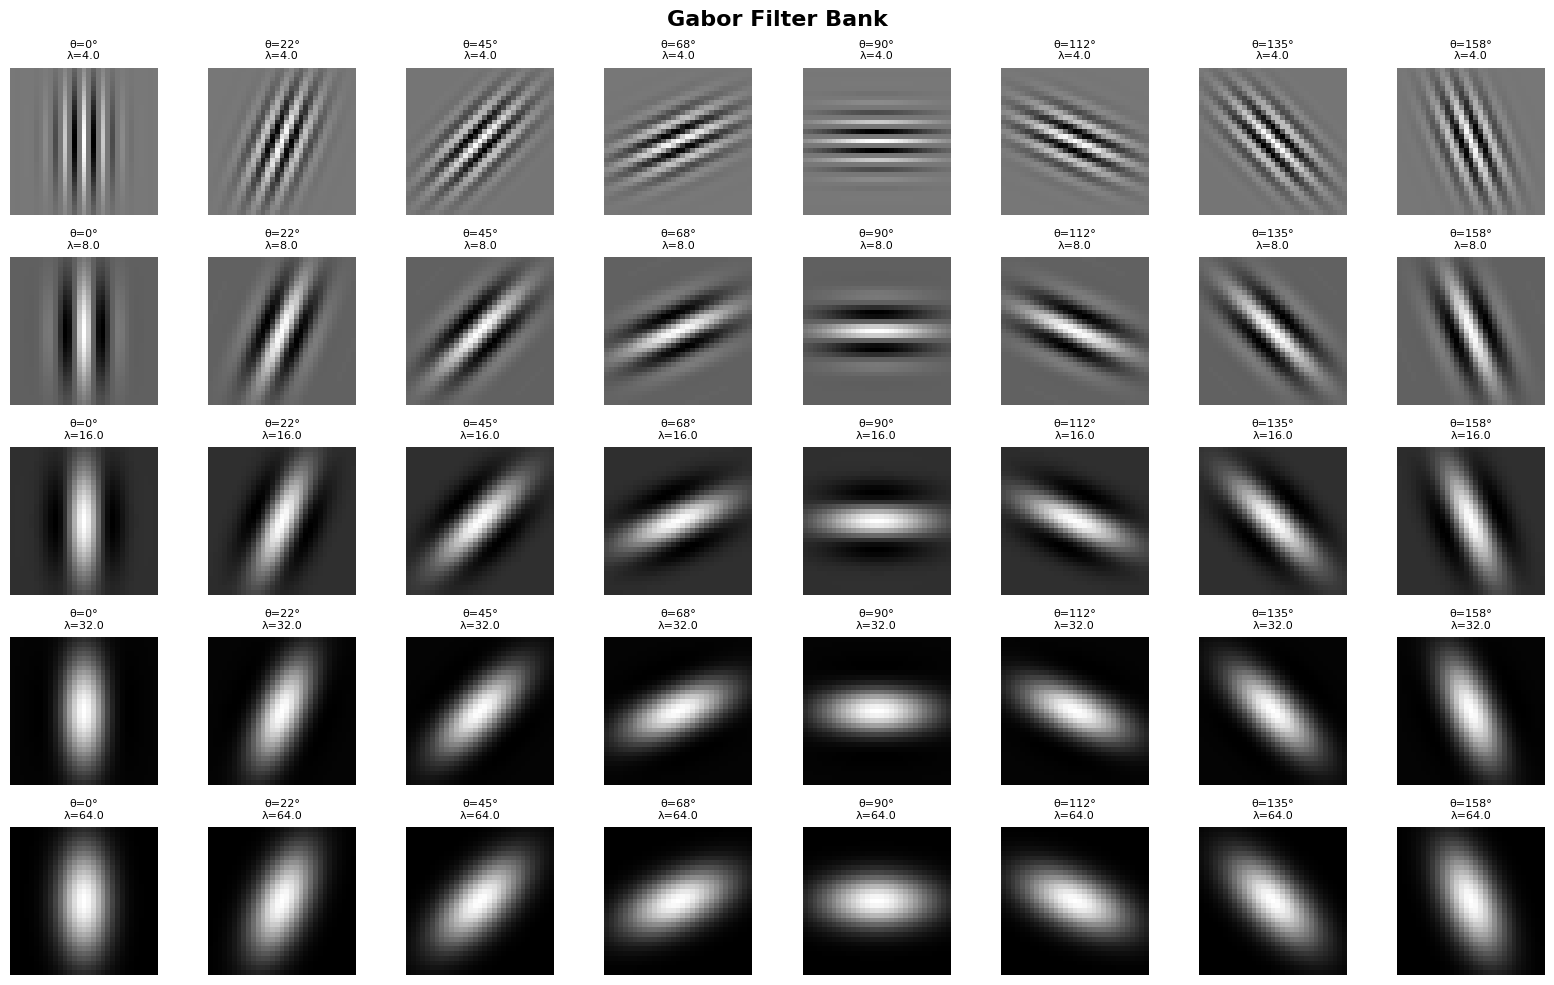

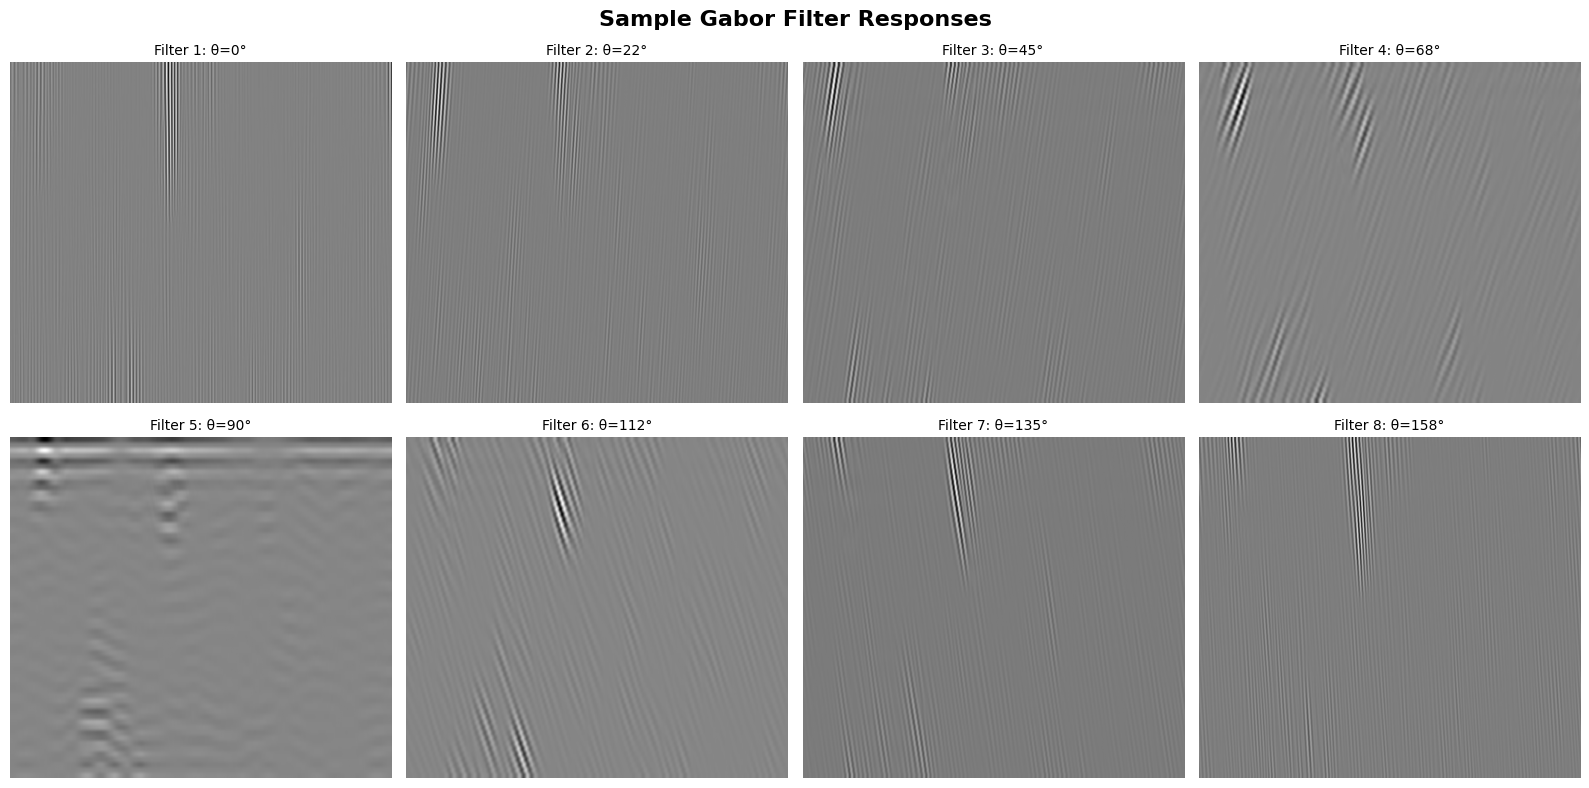

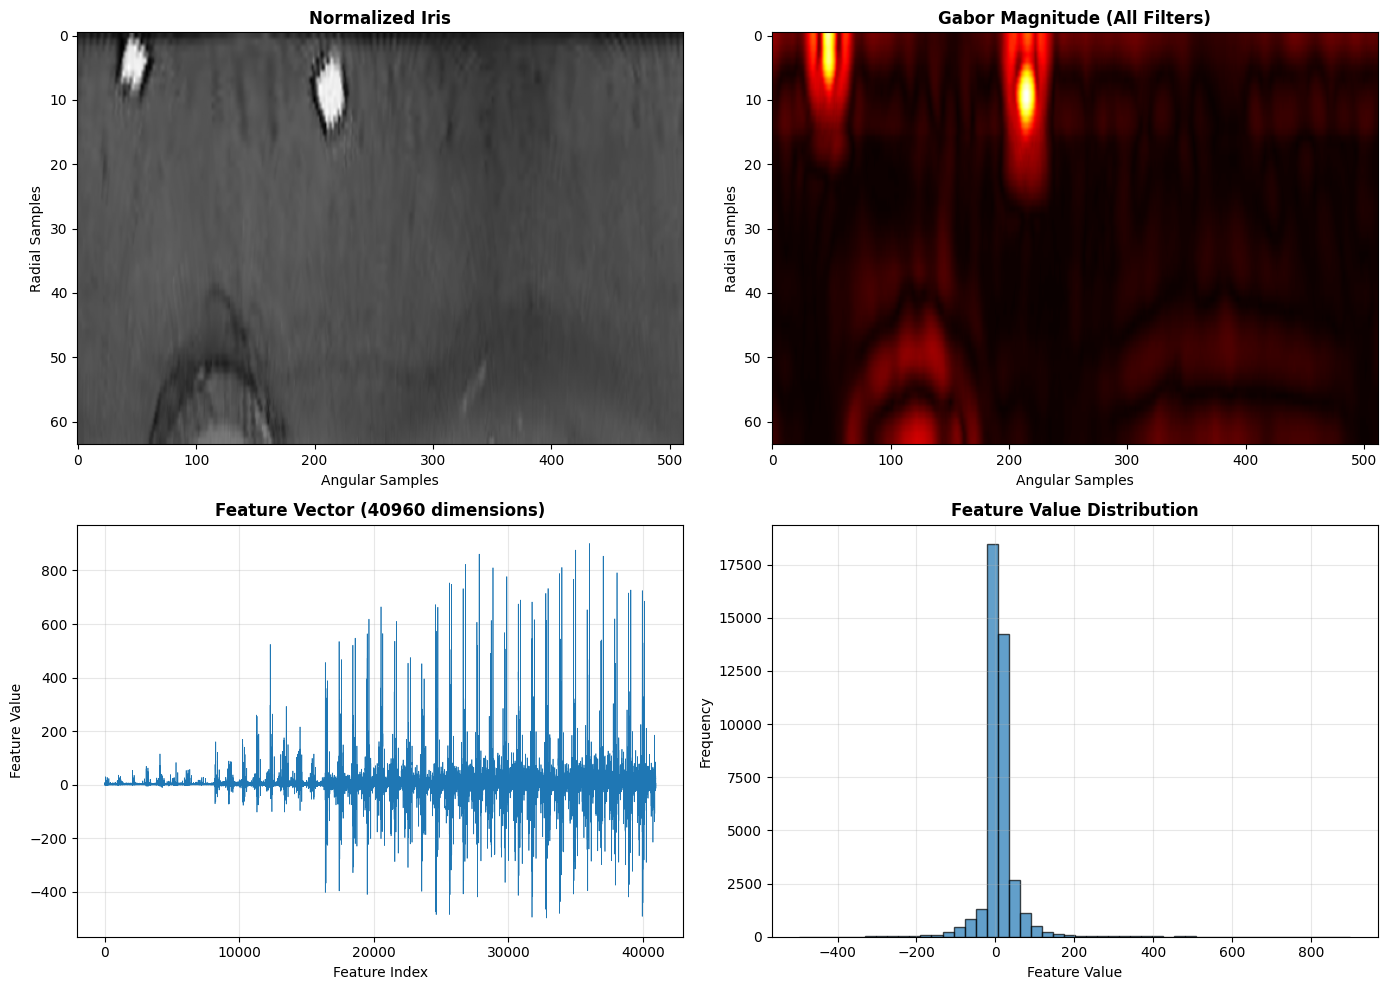

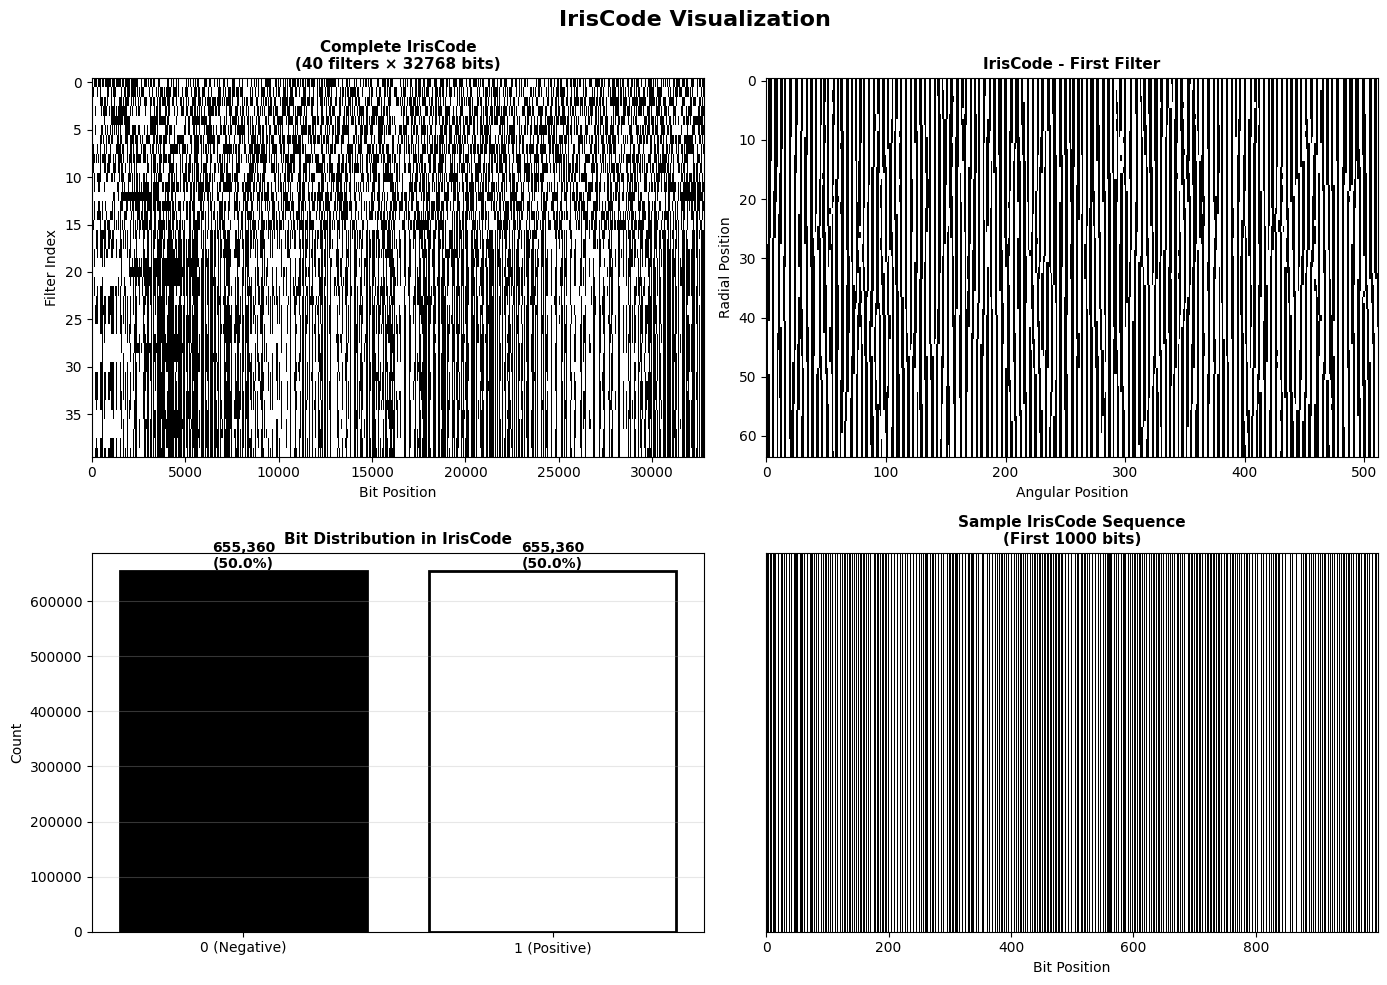


💾 Feature vector saved: outputs/features/feature_vector.npy
💾 IrisCode saved: outputs/features/iris_code.npy
💾 IrisCode mask saved: outputs/features/iris_code_mask.npy
💾 Gabor filters saved: outputs/features/gabor_filters.pkl
💾 Feature info saved: outputs/features/feature_info.json

✓✓✓ PHASE 3 COMPLETE! ✓✓✓

📁 All outputs saved to: outputs/features


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pickle


def create_gabor_filters(num_orientations=8, num_scales=5, wavelength_base=4):
    """
    Create a bank of Gabor filters with improved parameters.

    Parameters:
        num_orientations: Number of orientations (typically 4-8)
        num_scales: Number of scales (typically 3-5)
        wavelength_base: Base wavelength value (default: 4 for iris texture)

    Returns:
        filters: List of Gabor filters
        params: Parameters for each filter
    """
    filters = []
    params = []

    ksize = 31
    sigma = 4.0  # Increased from 3.0 for better response
    gamma = 0.5
    psi = 0

    for scale in range(num_scales):
        wavelength = wavelength_base * (2 ** scale)

        for orientation in range(num_orientations):
            theta = orientation * np.pi / num_orientations

            kernel = cv2.getGaborKernel(
                ksize=(ksize, ksize),
                sigma=sigma,
                theta=theta,
                lambd=wavelength,
                gamma=gamma,
                psi=psi,
                ktype=cv2.CV_32F
            )

            # Improved normalization: zero-mean and unit energy
            kernel = kernel - kernel.mean()
            kernel = kernel / (np.sqrt(np.sum(kernel**2)) + 1e-5)

            filters.append(kernel)
            params.append({
                'scale': scale,
                'orientation': orientation,
                'theta_deg': np.degrees(theta),
                'wavelength': wavelength
            })

    return filters, params


def apply_gabor_filters(normalized_iris, filters):
    """
    Apply Gabor filters to normalized iris.

    Parameters:
        normalized_iris: Normalized image (2D array)
        filters: List of Gabor filters

    Returns:
        responses: List of responses for each filter
        magnitude: Total magnitude of responses
    """
    responses = []
    image = normalized_iris.astype(np.float32)

    for gabor_filter in filters:
        filtered = cv2.filter2D(image, cv2.CV_32F, gabor_filter)
        responses.append(filtered)

    magnitude = np.zeros_like(image)
    for response in responses:
        magnitude += np.abs(response)
    magnitude = magnitude / len(filters)

    return responses, magnitude


def extract_gabor_features(normalized_iris, filters, block_size=8):
    """
    Extract feature vector from Gabor responses.

    Parameters:
        normalized_iris: Normalized image
        filters: List of Gabor filters
        block_size: Block size for feature extraction

    Returns:
        feature_vector: 1D feature vector
    """
    responses, magnitude = apply_gabor_filters(normalized_iris, filters)

    h, w = normalized_iris.shape
    features = []

    for response in responses:
        for i in range(0, h, block_size):
            for j in range(0, w, block_size):
                block = response[i:i+block_size, j:j+block_size]

                if block.size > 0:
                    mean_val = np.mean(block)
                    std_val = np.std(block)
                    features.append(mean_val)
                    features.append(std_val)

    return np.array(features)


def create_iris_code(normalized_iris, filters):
    """
    Create IrisCode using improved Gabor Wavelets encoding.

    Parameters:
        normalized_iris: Normalized image
        filters: List of Gabor filters

    Returns:
        iris_code: Binary iris code
        mask: Validity mask
    """
    image = normalized_iris.astype(np.float32)
    h, w = image.shape

    # Improved preprocessing: Use CLAHE for better local contrast
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(normalized_iris)

    # Normalize to [0, 1]
    image = enhanced.astype(np.float32) / 255.0

    iris_code = []
    responses = []

    for idx, gabor_filter in enumerate(filters):
        # Apply filter
        response = cv2.filter2D(image, cv2.CV_32F, gabor_filter)
        responses.append(response)

        # Encode using MEDIAN (more robust than mean)
        median_val = np.median(response)
        code = (response > median_val).astype(np.uint8)
        iris_code.append(code.flatten())

    iris_code = np.concatenate(iris_code)

    # Create improved mask based on response strength
    mask = []
    for response in responses:
        abs_response = np.abs(response)
        # Mark bottom 10% as invalid
        threshold = np.percentile(abs_response, 10)
        valid = (abs_response > threshold).astype(np.uint8)
        mask.append(valid.flatten())

    mask = np.concatenate(mask)

    return iris_code, mask


def visualize_feature_extraction(normalized, filters, responses, magnitude,
                                 feature_vector, params, iris_code, output_dir):
    """
    Visualize feature extraction results.
    """
    num_orientations = max([p['orientation'] for p in params]) + 1
    num_scales = max([p['scale'] for p in params]) + 1

    # Figure 1: Gabor Filters
    fig1, axes = plt.subplots(num_scales, num_orientations, figsize=(16, 10))
    fig1.suptitle('Gabor Filter Bank', fontsize=16, fontweight='bold')

    for idx, (filt, param) in enumerate(zip(filters, params)):
        scale = param['scale']
        orient = param['orientation']
        ax = axes[scale, orient] if num_scales > 1 else axes[orient]
        ax.imshow(filt, cmap='gray')
        ax.set_title(f"θ={param['theta_deg']:.0f}°\nλ={param['wavelength']:.1f}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'gabor_filters.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Figure 2: Sample Responses
    fig2, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig2.suptitle('Sample Gabor Filter Responses', fontsize=16, fontweight='bold')

    for i in range(min(8, len(responses))):
        ax = axes[i // 4, i % 4]
        ax.imshow(responses[i], cmap='gray', aspect='auto')
        ax.set_title(f"Filter {i+1}: θ={params[i]['theta_deg']:.0f}°", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'gabor_responses.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Figure 3: Feature Results
    fig3, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].imshow(normalized, cmap='gray', aspect='auto')
    axes[0, 0].set_title('Normalized Iris', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Angular Samples')
    axes[0, 0].set_ylabel('Radial Samples')

    axes[0, 1].imshow(magnitude, cmap='hot', aspect='auto')
    axes[0, 1].set_title('Gabor Magnitude (All Filters)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Angular Samples')
    axes[0, 1].set_ylabel('Radial Samples')

    axes[1, 0].plot(feature_vector, linewidth=0.5)
    axes[1, 0].set_title(f'Feature Vector ({len(feature_vector)} dimensions)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Feature Index')
    axes[1, 0].set_ylabel('Feature Value')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].hist(feature_vector, bins=50, edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Feature Value Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Feature Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'feature_results.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Figure 4: IrisCode
    h, w = normalized.shape
    total_filters = len(filters)
    bits_per_filter = h * w
    iris_code_2d = iris_code.reshape(total_filters, -1)

    fig4, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig4.suptitle('IrisCode Visualization', fontsize=16, fontweight='bold')

    axes[0, 0].imshow(iris_code_2d, cmap='binary', aspect='auto', interpolation='nearest')
    axes[0, 0].set_title(f'Complete IrisCode\n({total_filters} filters × {bits_per_filter} bits)',
                        fontsize=11, fontweight='bold')
    axes[0, 0].set_xlabel('Bit Position')
    axes[0, 0].set_ylabel('Filter Index')

    first_filter_code = iris_code[:bits_per_filter].reshape(h, w)
    axes[0, 1].imshow(first_filter_code, cmap='binary', aspect='auto', interpolation='nearest')
    axes[0, 1].set_title('IrisCode - First Filter', fontsize=11, fontweight='bold')
    axes[0, 1].set_xlabel('Angular Position')
    axes[0, 1].set_ylabel('Radial Position')

    ones_count = np.sum(iris_code)
    zeros_count = len(iris_code) - ones_count
    axes[1, 0].bar(['0 (Negative)', '1 (Positive)'], [zeros_count, ones_count],
                  color=['black', 'white'], edgecolor='black', linewidth=2)
    axes[1, 0].set_title('Bit Distribution in IrisCode', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    total = len(iris_code)
    axes[1, 0].text(0, zeros_count, f'{zeros_count:,}\n({zeros_count/total*100:.1f}%)',
                   ha='center', va='bottom', fontweight='bold')
    axes[1, 0].text(1, ones_count, f'{ones_count:,}\n({ones_count/total*100:.1f}%)',
                   ha='center', va='bottom', fontweight='bold')

    sample_size = min(1000, len(iris_code))
    sample_code = iris_code[:sample_size].reshape(1, -1)
    axes[1, 1].imshow(sample_code, cmap='binary', aspect='auto', interpolation='nearest')
    axes[1, 1].set_title(f'Sample IrisCode Sequence\n(First {sample_size} bits)',
                        fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel('Bit Position')
    axes[1, 1].set_yticks([])

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'iris_code.png'), dpi=150, bbox_inches='tight')
    plt.show()


def extract_features(normalization_dir='outputs/normalization',
                    output_dir='outputs/features',
                    num_orientations=8,
                    num_scales=5,
                    visualize=True):
    """
    Main function for feature extraction using normalized iris.

    Parameters:
        normalization_dir: Directory containing normalization outputs
        output_dir: Directory to save feature outputs
        num_orientations: Number of Gabor orientations
        num_scales: Number of Gabor scales
        visualize: Whether to show visualizations

    Returns:
        dict: Feature extraction results
    """
    print("\n" + "=" * 70)
    print("PHASE 3: FEATURE EXTRACTION")
    print("=" * 70)

    os.makedirs(output_dir, exist_ok=True)

    # Load normalized iris
    normalized_path = os.path.join(normalization_dir, 'normalized_iris.png')
    print(f"\nLoading normalized iris: {normalized_path}")

    if not os.path.exists(normalized_path):
        raise FileNotFoundError(f"❌ Normalized iris not found: {normalized_path}")

    normalized = cv2.imread(normalized_path, cv2.IMREAD_GRAYSCALE)
    print(f"✓ Normalized iris loaded: {normalized.shape}")

    # Quality check
    print(f"\nInput Quality Check:")
    print(f"  - Value range: [{normalized.min()}, {normalized.max()}]")
    print(f"  - Mean: {normalized.mean():.2f}")
    print(f"  - Std: {normalized.std():.2f}")

    zero_percentage = (normalized == 0).sum() / normalized.size * 100
    print(f"  - Zero pixels: {zero_percentage:.1f}%")

    if normalized.std() < 10:
        print(f"  ⚠️  WARNING: Very low contrast!")
    if zero_percentage > 50:
        print(f"  ⚠️  WARNING: High percentage of zero pixels!")

    # Step 1: Create Gabor filters
    print(f"\nStep 1: Creating Gabor filter bank...")
    print(f"  - Orientations: {num_orientations}")
    print(f"  - Scales: {num_scales}")
    filters, params = create_gabor_filters(num_orientations, num_scales)
    print(f"  ✓ Created {len(filters)} Gabor filters")

    # Step 2: Apply filters
    print(f"\nStep 2: Applying Gabor filters...")
    responses, magnitude = apply_gabor_filters(normalized, filters)
    print(f"  ✓ Generated {len(responses)} filter responses")

    # Step 3: Extract features
    print(f"\nStep 3: Extracting feature vector...")
    feature_vector = extract_gabor_features(normalized, filters, block_size=8)
    print(f"  ✓ Feature vector size: {len(feature_vector)} dimensions")

    # Step 4: Create IrisCode
    print(f"\nStep 4: Generating IrisCode...")
    iris_code, mask = create_iris_code(normalized, filters)
    print(f"  ✓ IrisCode size: {len(iris_code)} bits")

    # Check quality
    ones_ratio = iris_code.sum() / len(iris_code)
    print(f"  - Bit distribution: {ones_ratio*100:.1f}% ones, {(1-ones_ratio)*100:.1f}% zeros")

    if ones_ratio < 0.2 or ones_ratio > 0.8:
        print(f"  ⚠️  WARNING: Unbalanced IrisCode (should be ~50%)")
    else:
        print(f"  ✓ IrisCode has good bit distribution")

    valid_ratio = mask.sum() / len(mask)
    print(f"  - Valid bits: {valid_ratio*100:.1f}%")

    # Visualize
    if visualize:
        print("\nGenerating visualizations...")
        visualize_feature_extraction(normalized, filters, responses, magnitude,
                                     feature_vector, params, iris_code, output_dir)

    # Save feature vector
    feature_path = os.path.join(output_dir, 'feature_vector.npy')
    np.save(feature_path, feature_vector)
    print(f"\n💾 Feature vector saved: {feature_path}")

    # Save IrisCode
    iris_code_path = os.path.join(output_dir, 'iris_code.npy')
    np.save(iris_code_path, iris_code)
    print(f"💾 IrisCode saved: {iris_code_path}")

    # Save mask
    mask_path = os.path.join(output_dir, 'iris_code_mask.npy')
    np.save(mask_path, mask)
    print(f"💾 IrisCode mask saved: {mask_path}")

    # Save filters
    filters_path = os.path.join(output_dir, 'gabor_filters.pkl')
    with open(filters_path, 'wb') as f:
        pickle.dump({'filters': filters, 'params': params}, f)
    print(f"💾 Gabor filters saved: {filters_path}")

    # Save info
    feature_info = {
        'num_filters': len(filters),
        'num_orientations': num_orientations,
        'num_scales': num_scales,
        'feature_vector_size': len(feature_vector),
        'iris_code_size': len(iris_code),
        'ones_ratio': float(ones_ratio),
        'valid_ratio': float(valid_ratio),
        'is_balanced': bool(0.3 < ones_ratio < 0.7)
    }

    info_path = os.path.join(output_dir, 'feature_info.json')
    with open(info_path, 'w') as f:
        json.dump(feature_info, f, indent=2)
    print(f"💾 Feature info saved: {info_path}")

    results = {
        'feature_vector': feature_vector,
        'iris_code': iris_code,
        'mask': mask,
        'filters': filters,
        'params': params,
        'info': feature_info,
        'output_dir': output_dir
    }

    print("\n" + "=" * 70)
    print("✓✓✓ PHASE 3 COMPLETE! ✓✓✓")
    print("=" * 70)

    return results


if __name__ == "__main__":
    # Run feature extraction using results from Phase 2
    results = extract_features(
        normalization_dir='outputs/normalization',
        output_dir='outputs/features',
        num_orientations=8,
        num_scales=5,
        visualize=True
    )

    print(f"\n📁 All outputs saved to: {results['output_dir']}")

## Matching
Matches two iris images using functions from existing phase modules.



IRIS MATCHING: TWO IMAGES

[1/2] Processing Image 1: /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg
--------------------------------------------------------------------------------
  ✓ Complete

[2/2] Processing Image 2: /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L02.jpg
--------------------------------------------------------------------------------
  ✓ Complete

[3/3] Comparing Iris Codes...
--------------------------------------------------------------------------------

MATCHING RESULTS
Image 1:           /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg
Image 2:           /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L02.jpg

Hamming Distance:  0.3891
Threshold:         0.4100
Confidence:        61.09%

Decision:          ✓ MATCH (Same Person)

Processing Time:   1.07 seconds


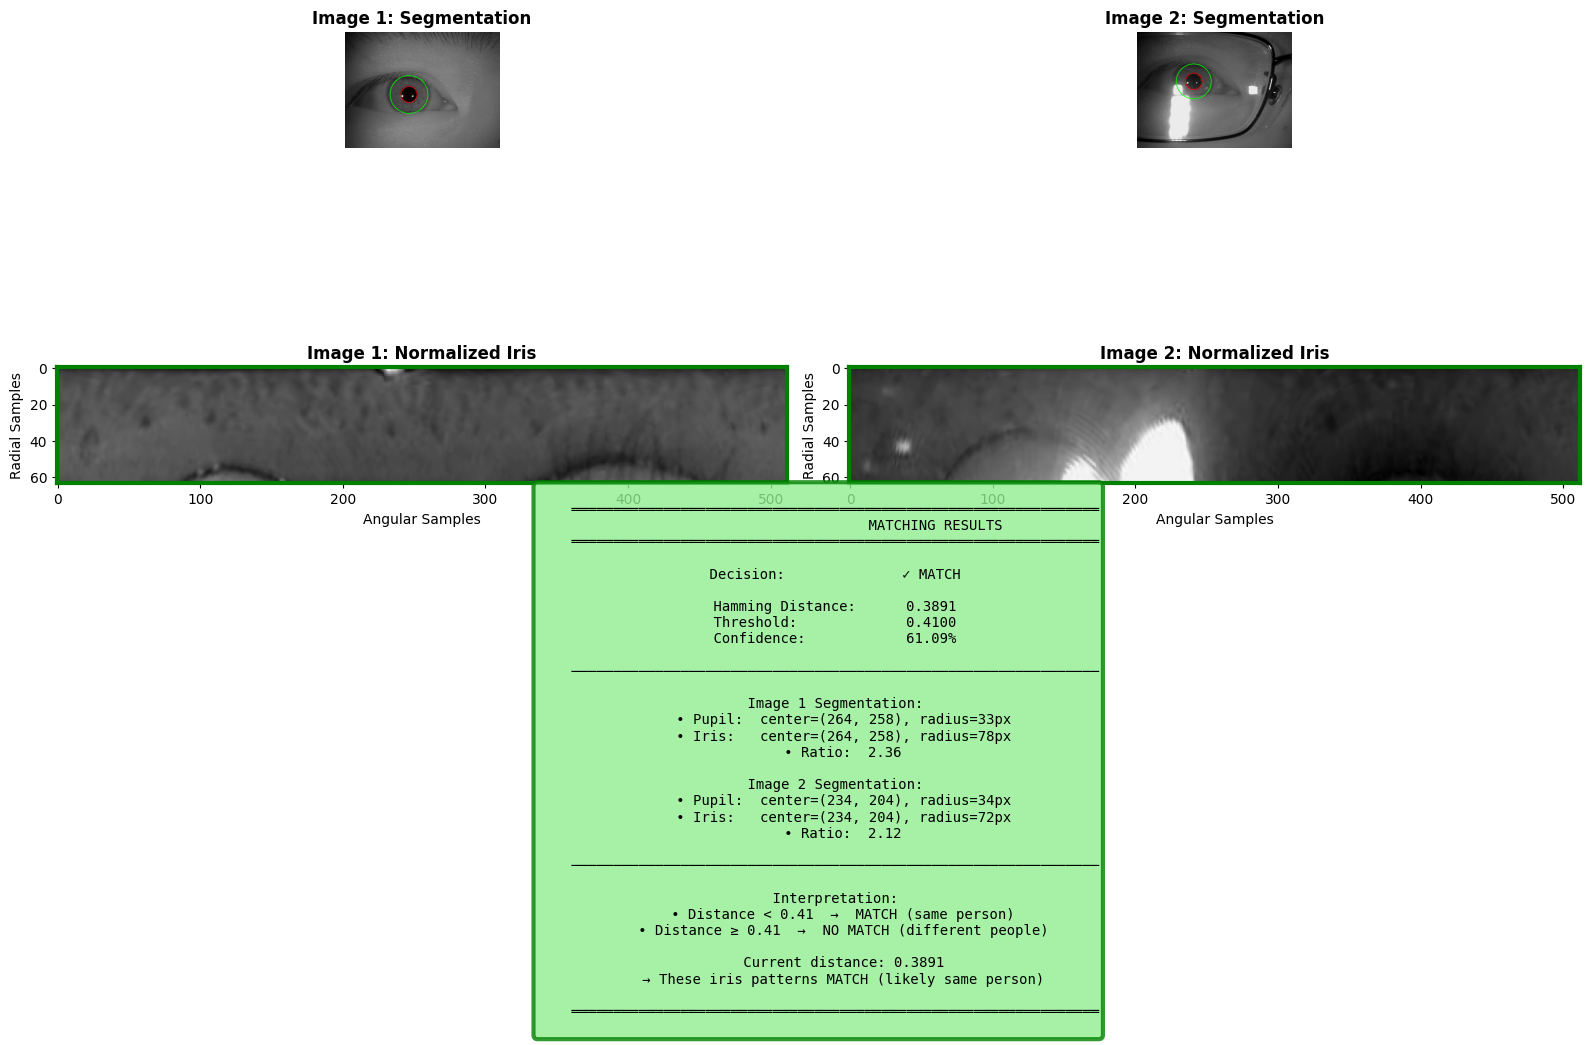

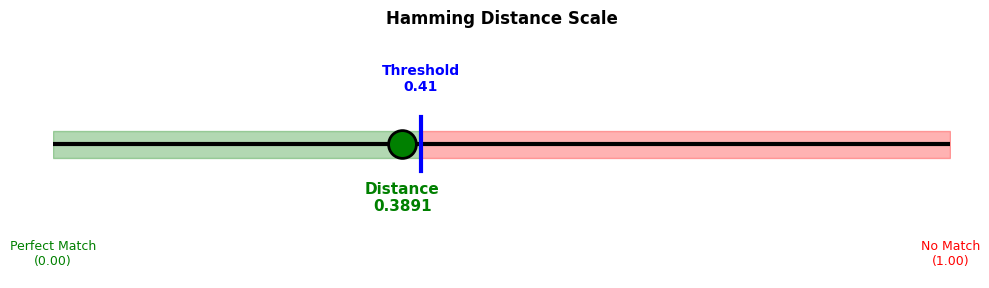

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime



def hamming_distance(code1, mask1, code2, mask2):
    """
    Calculate Hamming Distance between two IrisCodes.

    Parameters:
        code1, code2: Binary iris codes
        mask1, mask2: Validity masks

    Returns:
        distance: Hamming distance [0, 1]
    """
    valid_mask = mask1 & mask2

    if np.sum(valid_mask) == 0:
        return 1.0

    xor_result = np.bitwise_xor(code1, code2)
    diff_bits = np.sum(xor_result & valid_mask)
    total_bits = np.sum(valid_mask)

    return diff_bits / total_bits


def process_single_iris(image_path):
    """
    Process single iris image through all phases.

    Parameters:
        image_path: Path to iris image

    Returns:
        dict: Processing results including iris code
    """
    # Load image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    # Phase 1: Segmentation
    pupil_params = detect_pupil_hough(image, visualize=False)
    px, py, pr = pupil_params
    iris_r = detect_iris_radius(image, px, py, pr)

    # Phase 2: Normalization
    normalized, mask_norm = normalize_iris(
        image,
        (px, py),
        pr,
        (px, py),
        iris_r
    )

    # Phase 3: Feature Extraction
    filters, params = create_gabor_filters(num_orientations=8, num_scales=5)
    iris_code, mask = create_iris_code(normalized, filters)

    return {
        'image': image,
        'pupil_center': (px, py),
        'pupil_radius': pr,
        'iris_center': (px, py),
        'iris_radius': iris_r,
        'normalized': normalized,
        'iris_code': iris_code,
        'mask': mask
    }


def visualize_match_result(results1, results2, distance, threshold, is_match):
    """
    Visualize matching results.

    Parameters:
        results1, results2: Processing results for both images
        distance: Hamming distance
        threshold: Decision threshold
        is_match: Whether images match
    """
    # Color scheme based on match
    if is_match:
        border_color = 'green'
        result_text = '✓ MATCH'
        result_color = 'lightgreen'
    else:
        border_color = 'red'
        result_text = '✗ NO MATCH'
        result_color = 'lightcoral'

    fig = plt.figure(figsize=(16, 10))

    # Image 1 - Segmentation
    ax1 = plt.subplot(3, 2, 1)
    result1 = cv2.cvtColor(results1['image'], cv2.COLOR_GRAY2BGR)
    px1, py1 = results1['pupil_center']
    pr1 = results1['pupil_radius']
    ix1, iy1 = results1['iris_center']
    ir1 = results1['iris_radius']
    cv2.circle(result1, (ix1, iy1), ir1, (0, 255, 0), 2)
    cv2.circle(result1, (px1, py1), pr1, (0, 0, 255), 2)
    ax1.imshow(cv2.cvtColor(result1, cv2.COLOR_BGR2RGB))
    ax1.set_title('Image 1: Segmentation', fontsize=12, fontweight='bold')
    ax1.axis('off')
    for spine in ax1.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    # Image 2 - Segmentation
    ax2 = plt.subplot(3, 2, 2)
    result2 = cv2.cvtColor(results2['image'], cv2.COLOR_GRAY2BGR)
    px2, py2 = results2['pupil_center']
    pr2 = results2['pupil_radius']
    ix2, iy2 = results2['iris_center']
    ir2 = results2['iris_radius']
    cv2.circle(result2, (ix2, iy2), ir2, (0, 255, 0), 2)
    cv2.circle(result2, (px2, py2), pr2, (0, 0, 255), 2)
    ax2.imshow(cv2.cvtColor(result2, cv2.COLOR_BGR2RGB))
    ax2.set_title('Image 2: Segmentation', fontsize=12, fontweight='bold')
    ax2.axis('off')
    for spine in ax2.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    # Image 1 - Normalized
    ax3 = plt.subplot(3, 2, 3)
    ax3.imshow(results1['normalized'], cmap='gray', aspect='auto')
    ax3.set_title('Image 1: Normalized Iris', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Angular Samples')
    ax3.set_ylabel('Radial Samples')
    for spine in ax3.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    # Image 2 - Normalized
    ax4 = plt.subplot(3, 2, 4)
    ax4.imshow(results2['normalized'], cmap='gray', aspect='auto')
    ax4.set_title('Image 2: Normalized Iris', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Angular Samples')
    ax4.set_ylabel('Radial Samples')
    for spine in ax4.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    # Results
    ax5 = plt.subplot(3, 1, 3)
    ax5.axis('off')

    result_info = f"""
    ═══════════════════════════════════════════════════════════════
                            MATCHING RESULTS
    ═══════════════════════════════════════════════════════════════

    Decision:              {result_text}

    Hamming Distance:      {distance:.4f}
    Threshold:             {threshold:.4f}
    Confidence:            {(1.0 - distance)*100:.2f}%

    ───────────────────────────────────────────────────────────────

    Image 1 Segmentation:
      • Pupil:  center=({px1}, {py1}), radius={pr1}px
      • Iris:   center=({ix1}, {iy1}), radius={ir1}px
      • Ratio:  {ir1/pr1:.2f}

    Image 2 Segmentation:
      • Pupil:  center=({px2}, {py2}), radius={pr2}px
      • Iris:   center=({ix2}, {iy2}), radius={ir2}px
      • Ratio:  {ir2/pr2:.2f}

    ───────────────────────────────────────────────────────────────

    Interpretation:
      • Distance < {threshold}  →  MATCH (same person)
      • Distance ≥ {threshold}  →  NO MATCH (different people)

      Current distance: {distance:.4f}
      → {'These iris patterns MATCH (likely same person)' if is_match else 'These iris patterns DO NOT MATCH (likely different people)'}

    ═══════════════════════════════════════════════════════════════
    """

    ax5.text(0.5, 0.5, result_info, ha='center', va='center',
            fontsize=10, family='monospace',
            bbox=dict(boxstyle='round', facecolor=result_color, alpha=0.8,
                     edgecolor=border_color, linewidth=3))

    plt.tight_layout()
    plt.show()

    # Distance gauge
    fig2, ax = plt.subplots(figsize=(10, 3))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    scale_y = 0.5
    ax.plot([0, 1], [scale_y, scale_y], 'k-', linewidth=3)

    ax.plot([threshold, threshold], [scale_y-0.1, scale_y+0.1], 'b-', linewidth=3)
    ax.text(threshold, scale_y+0.2, f"Threshold\n{threshold:.2f}",
            ha='center', fontsize=10, fontweight='bold', color='blue')

    marker_color = 'green' if is_match else 'red'
    ax.plot([distance], [scale_y], 'o', markersize=20,
            color=marker_color, markeredgecolor='black', markeredgewidth=2)
    ax.text(distance, scale_y-0.25, f"Distance\n{distance:.4f}",
            ha='center', fontsize=11, fontweight='bold', color=marker_color)

    ax.text(0, scale_y-0.45, 'Perfect Match\n(0.00)', ha='center', fontsize=9, color='green')
    ax.text(1, scale_y-0.45, 'No Match\n(1.00)', ha='center', fontsize=9, color='red')
    ax.text(0.5, scale_y+0.45, 'Hamming Distance Scale', ha='center', fontsize=12, fontweight='bold')

    ax.fill_between([0, threshold], scale_y-0.05, scale_y+0.05,
                    alpha=0.3, color='green', label='Match Region')
    ax.fill_between([threshold, 1], scale_y-0.05, scale_y+0.05,
                    alpha=0.3, color='red', label='No Match Region')

    plt.tight_layout()
    plt.show()


def match_two_irises(image1_path, image2_path, threshold=0.35, visualize=True):
    """
    Match two iris images.

    Parameters:
        image1_path: Path to first iris image
        image2_path: Path to second iris image
        threshold: Decision threshold (default: 0.35)
        visualize: Whether to show visualization

    Returns:
        dict: Matching results
    """
    print("\n" + "=" * 80)
    print("IRIS MATCHING: TWO IMAGES")
    print("=" * 80)

    start_time = datetime.now()

    # Process Image 1
    print(f"\n[1/2] Processing Image 1: {image1_path}")
    print("-" * 80)
    results1 = process_single_iris(image1_path)
    print("  ✓ Complete")

    # Process Image 2
    print(f"\n[2/2] Processing Image 2: {image2_path}")
    print("-" * 80)
    results2 = process_single_iris(image2_path)
    print("  ✓ Complete")

    # Calculate Hamming distance
    print(f"\n[3/3] Comparing Iris Codes...")
    print("-" * 80)
    distance = hamming_distance(
        results1['iris_code'],
        results1['mask'],
        results2['iris_code'],
        results2['mask']
    )

    is_match = distance < threshold

    end_time = datetime.now()
    total_time = (end_time - start_time).total_seconds()

    # Print results
    print("\n" + "=" * 80)
    print("MATCHING RESULTS")
    print("=" * 80)
    print(f"Image 1:           {image1_path}")
    print(f"Image 2:           {image2_path}")
    print(f"\nHamming Distance:  {distance:.4f}")
    print(f"Threshold:         {threshold:.4f}")
    print(f"Confidence:        {(1.0 - distance)*100:.2f}%")
    print(f"\nDecision:          {'✓ MATCH (Same Person)' if is_match else '✗ NO MATCH (Different People)'}")
    print(f"\nProcessing Time:   {total_time:.2f} seconds")
    print("=" * 80)

    # Visualize
    if visualize:
        visualize_match_result(results1, results2, distance, threshold, is_match)

    return {
        'distance': distance,
        'threshold': threshold,
        'is_match': is_match,
        'confidence': 1.0 - distance,
        'processing_time': total_time
    }


# ============================================================================
# MAIN - EXAMPLES
# ============================================================================

if __name__ == "__main__":

    # Example: Different people (should NOT match)
    result = match_two_irises(
        image1_path='/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg',
        image2_path='/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L02.jpg',
        threshold=0.41,
        visualize=True
    )

## Testing the dataset
Tests the system on multiple iris pairs and calculates accuracy metrics.

IRIS RECOGNITION RESEARCH EXPERIMENTS
Comprehensive Analysis of Classical Methods on CASIA-Iris-Thousand


Starting experiments...
This may take some time depending on dataset size and parameters.


################################################################################
# EXPERIMENT 1: Baseline Recognition Accuracy (RQ1)
################################################################################

RQ1: BASELINE RECOGNITION ACCURACY EXPERIMENT


Processing images...
  Processed 10/400 images...
  Processed 20/400 images...
  Processed 30/400 images...
  Processed 40/400 images...
  Processed 50/400 images...
  Processed 60/400 images...
  Processed 70/400 images...
  Processed 80/400 images...
  Processed 90/400 images...
  Processed 100/400 images...
  Processed 110/400 images...
  Processed 120/400 images...
  Processed 130/400 images...
  Processed 140/400 images...
  Processed 150/400 images...
  Processed 160/400 images...
  Processed 170/400 images...
  Processed 180/

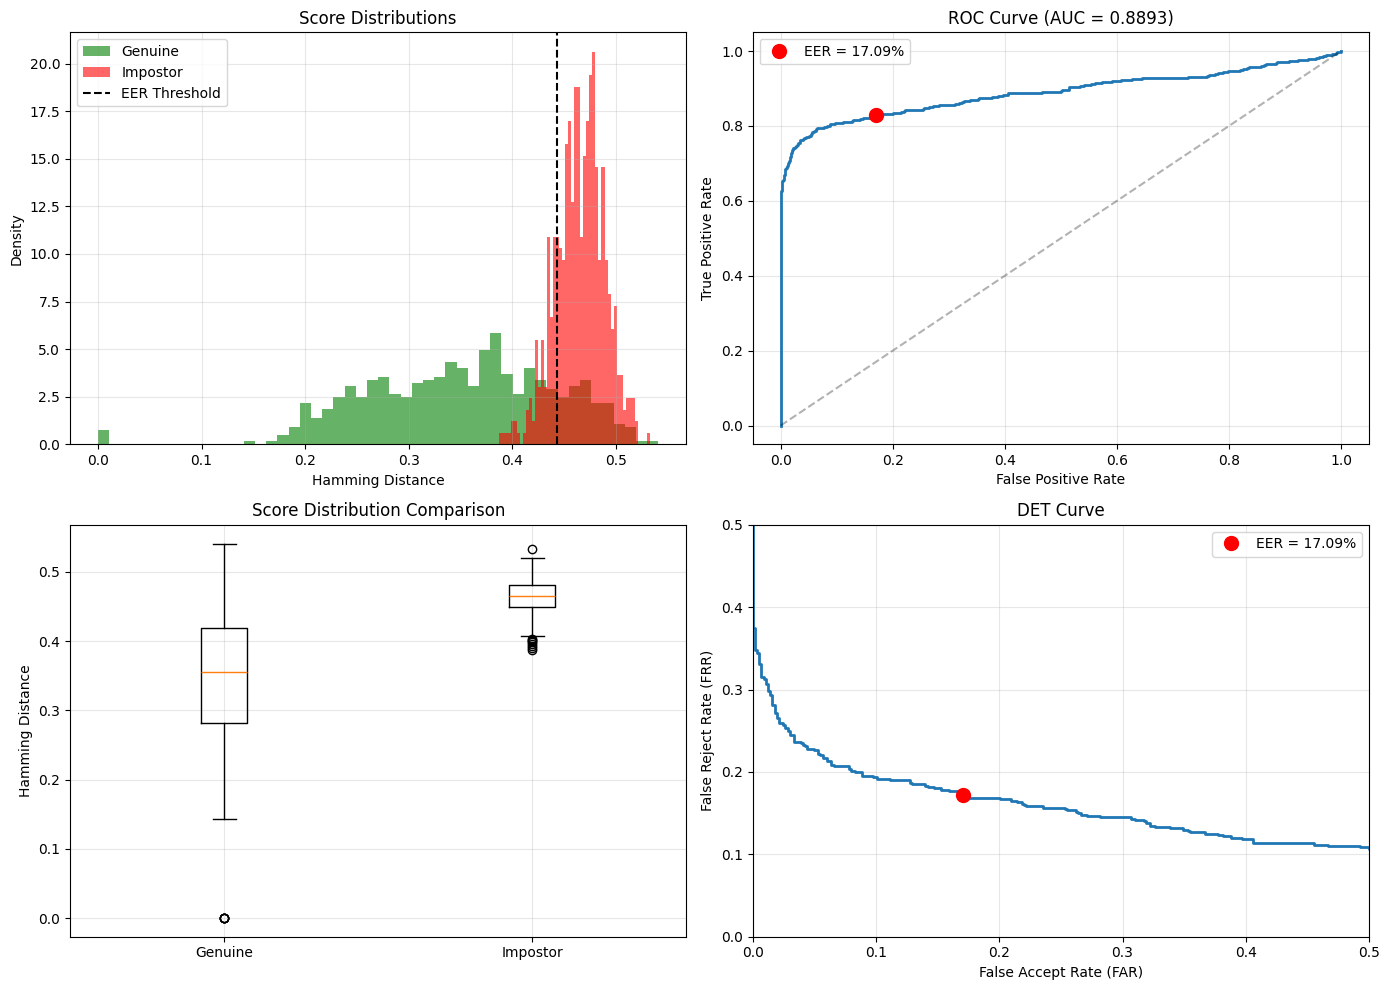


Results saved to research_experiments/rq1_baseline

################################################################################
# EXPERIMENT 2: Gabor Filter Parameter Analysis (RQ2)
################################################################################

RQ2: GABOR FILTER PARAMETER ANALYSIS

Total images: 180

Processing images (segmentation + normalization)...
  Processed 20/180 images...
  Processed 40/180 images...
  Processed 60/180 images...
  Processed 80/180 images...
  Processed 100/180 images...
  Processed 120/180 images...
  Processed 140/180 images...
  Processed 160/180 images...
  Processed 180/180 images...

Successfully processed 180 images

Testing configuration: 4ori_3scale_λ4
Creating IrisCodes with 12 Gabor filters...

Results for 4ori_3scale_λ4:
  EER: 14.00%
  d-prime: 1.605
  Genuine: 0.3897 ± 0.0740
  Impostor: 0.4749 ± 0.0127
  Processing time: 11.60s

Testing configuration: 6ori_4scale_λ4
Creating IrisCodes with 24 Gabor filters...

Results for 

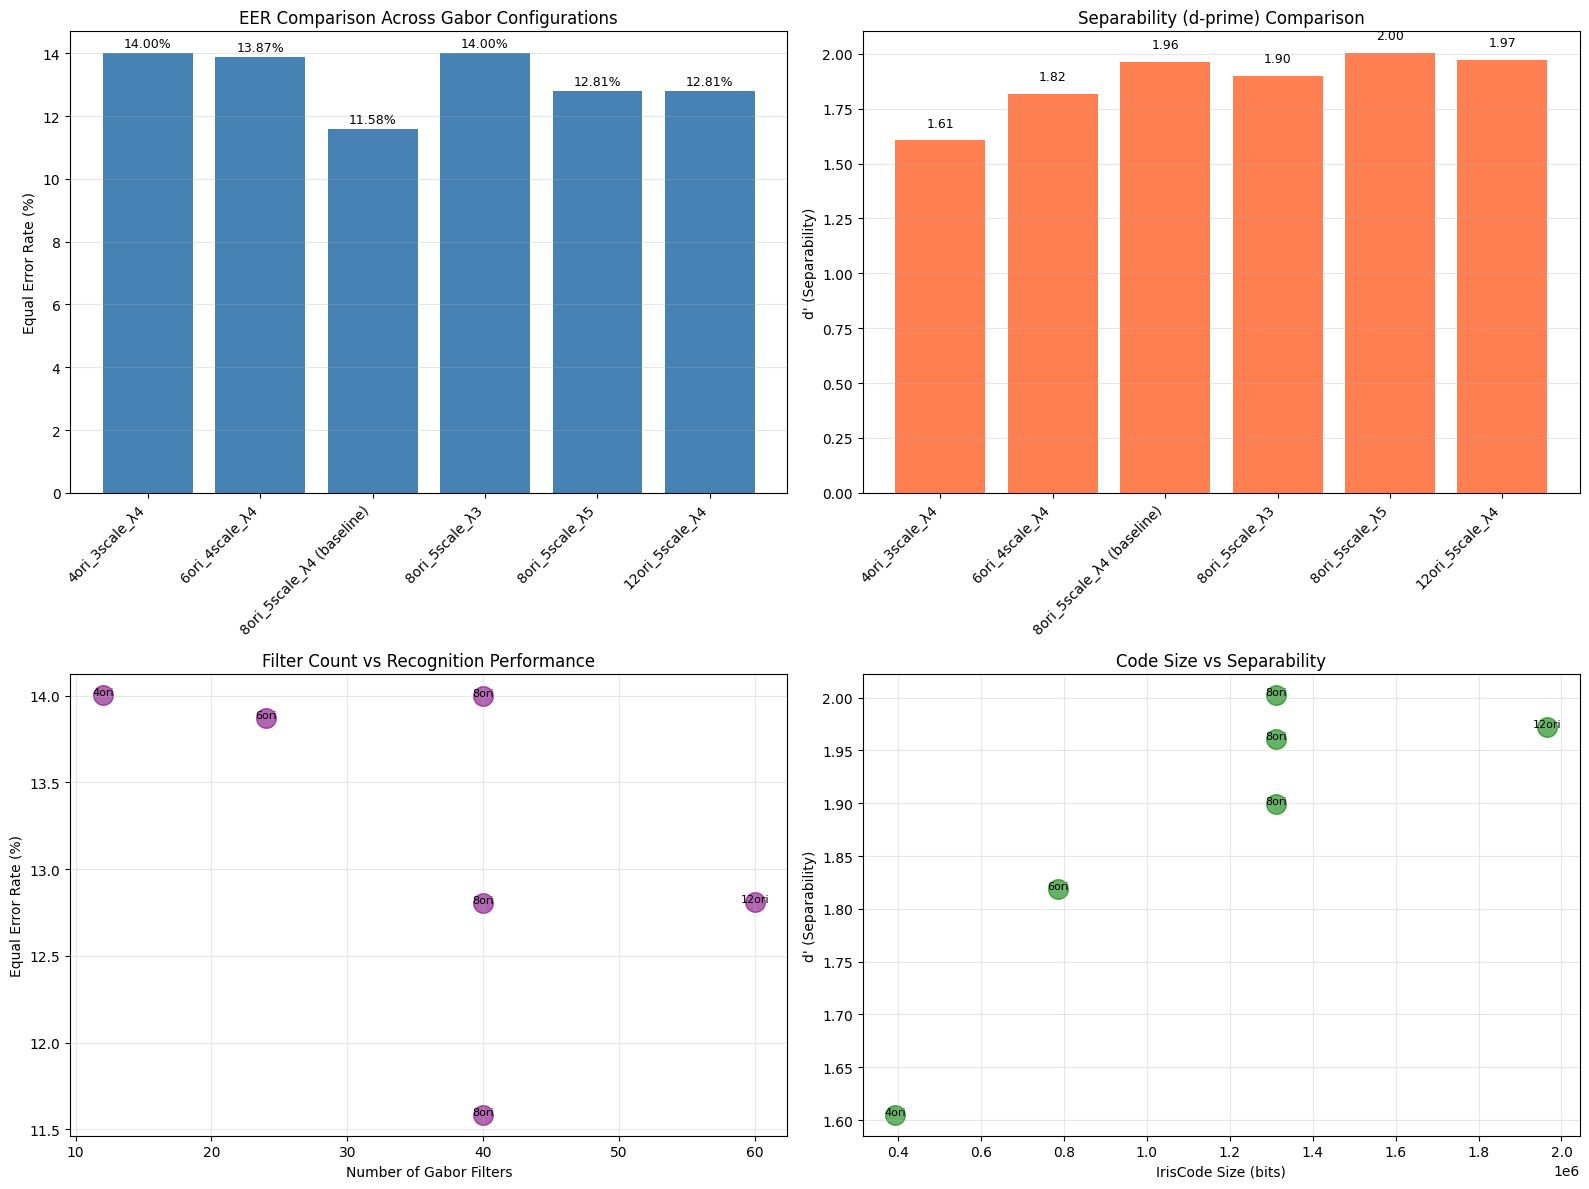


            Configuration  Orientations  Scales  Wavelength  Num Filters  Code Size EER (%)    d' Time (s)
           4ori_3scale_λ4             4       3           4           12     393216   14.00 1.605    11.60
           6ori_4scale_λ4             6       4           4           24     786432   13.87 1.819    21.41
8ori_5scale_λ4 (baseline)             8       5           4           40    1310720   11.58 1.961    37.08
           8ori_5scale_λ3             8       5           3           40    1310720   14.00 1.900    35.68
           8ori_5scale_λ5             8       5           5           40    1310720   12.81 2.002    36.50
          12ori_5scale_λ4            12       5           4           60    1966080   12.81 1.972    53.16

Results saved to research_experiments/rq2_gabor

################################################################################
# EXPERIMENT 3: Normalization Resolution Analysis (RQ3)
###############################################################

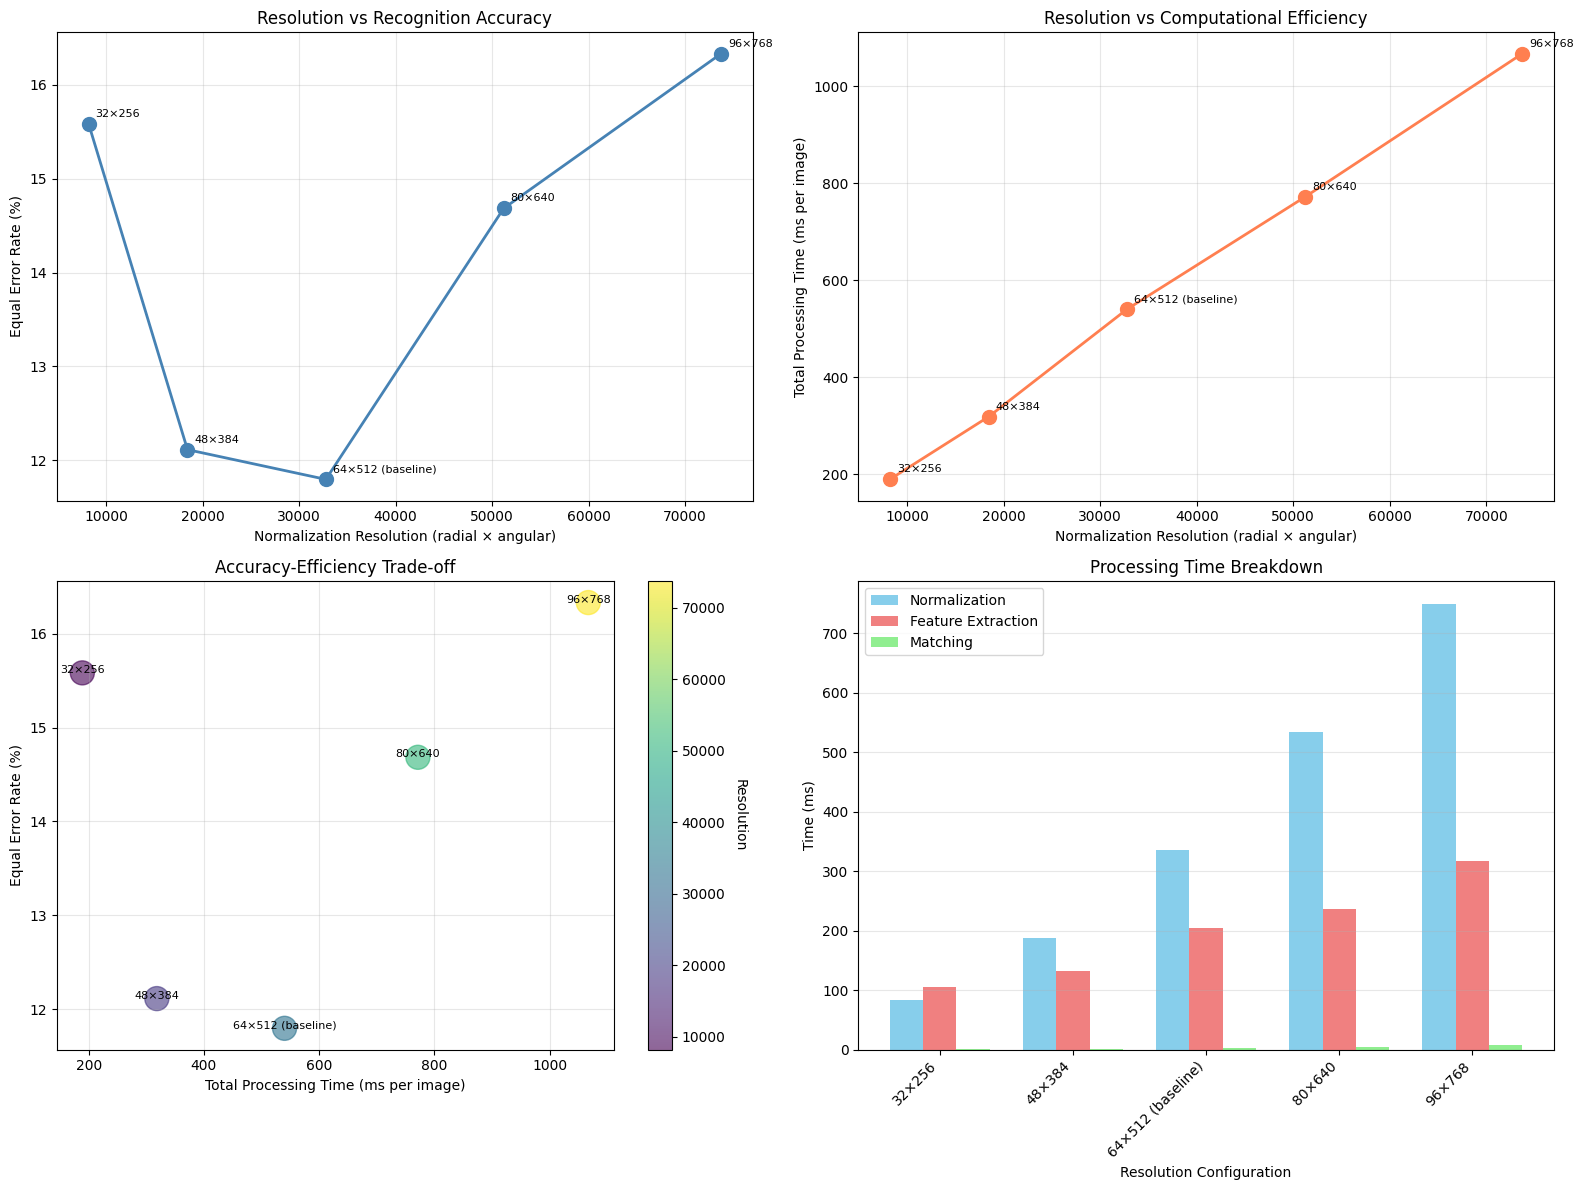


       Resolution  Total Pixels EER (%)    d' Norm Time (ms) Feature Time (ms) Match Time (ms) Total Time (ms)
           32×256          8192   15.58 1.985          83.76            105.27          1.1956          189.04
           48×384         18432   12.11 2.098         186.85            131.47          1.7742          318.32
64×512 (baseline)         32768   11.79 1.921         336.20            203.70          3.1547          539.90
           80×640         51200   14.68 1.757         534.33            236.92          4.6632          771.26
           96×768         73728   16.33 1.558         749.88            317.03          7.7594         1066.90

Results saved to research_experiments/rq3_resolution

################################################################################
# EXPERIMENT 4: Same-Eye vs Cross-Eye Comparison (RQ4)
################################################################################

RQ4: SAME-EYE VS CROSS-EYE COMPARISON ANALYSIS


Processing 

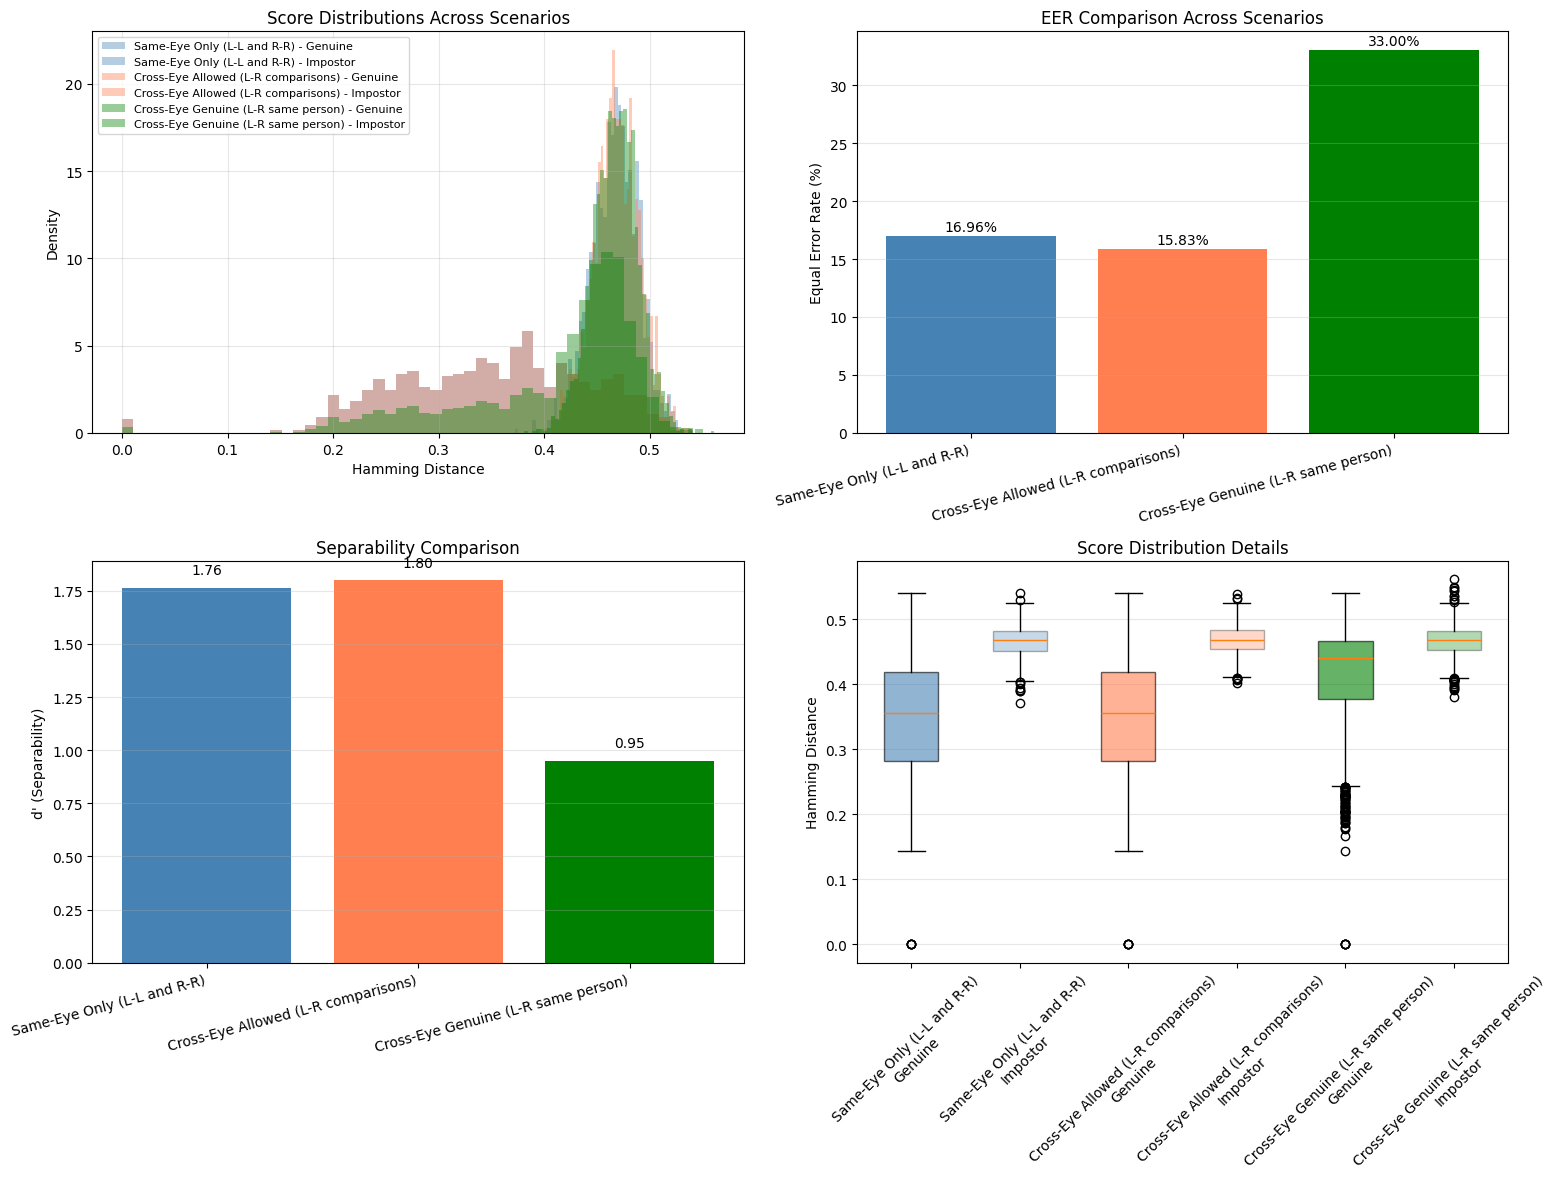


                           Scenario  Num Genuine  Num Impostor EER (%) Accuracy (%)    d' Genuine Mean Impostor Mean
        Same-Eye Only (L-L and R-R)          600          1200   16.96        83.06 1.765       0.3508        0.4668
Cross-Eye Allowed (L-R comparisons)          600          1200   15.83        84.11 1.800       0.3508        0.4688
Cross-Eye Genuine (L-R same person)         1400          2800   33.00        67.02 0.950       0.4114        0.4679

Results saved to research_experiments/rq4_eye_comparison

################################################################################
# EXPERIMENT 5: Failure Mode Analysis (RQ5)
################################################################################

RQ5: FAILURE MODE ANALYSIS


Processing images and calculating quality metrics...
  Processed 20/400 images...
  Processed 40/400 images...
  Processed 60/400 images...
  Processed 80/400 images...
  Processed 100/400 images...
  Processed 120/400 images...
  Proce

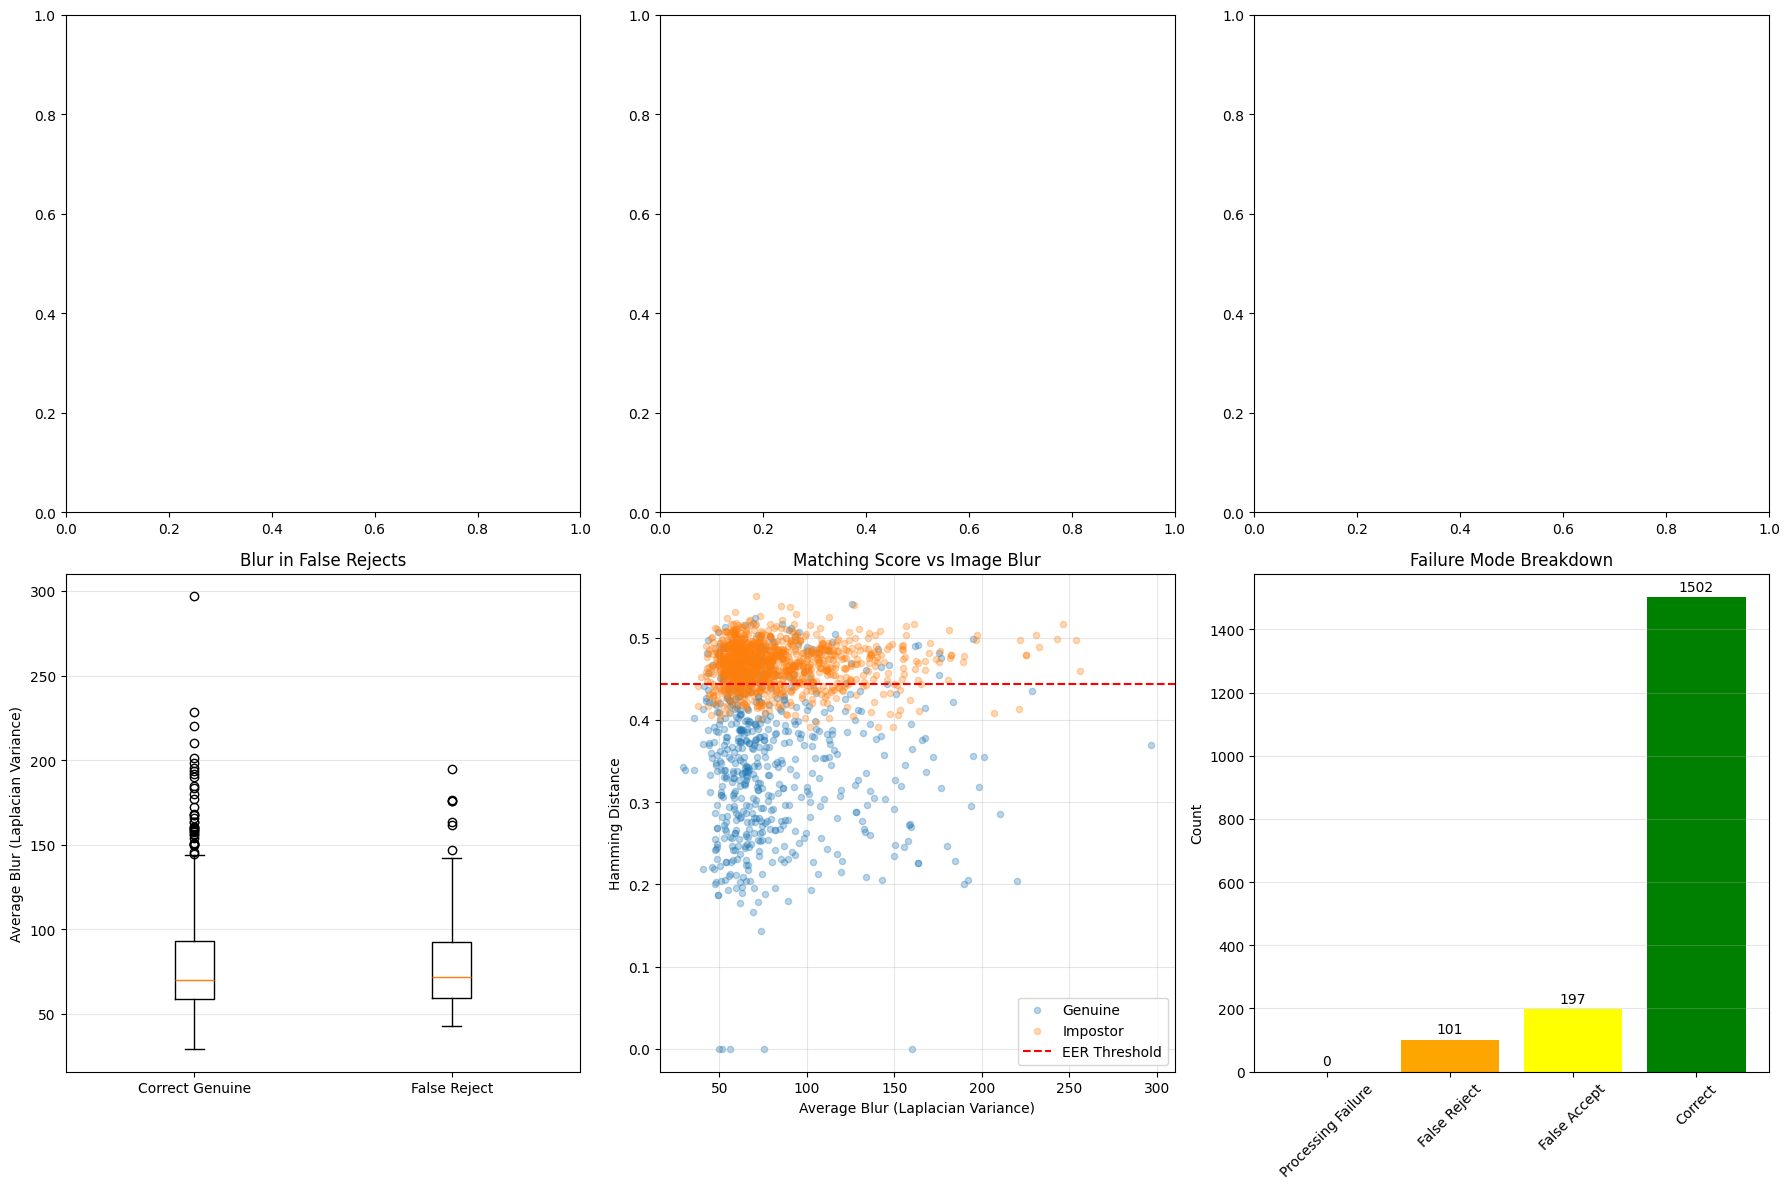


FAILURE MODE SUMMARY
Total images processed: 400
Processing success rate: 100.0%

Matching Failures:
  False Reject Rate: 16.83%
  False Accept Rate: 16.42%

Quality Correlation:
  False rejects with quality issues: 101/101 (100.0%)
  False accepts with quality issues: 197/197 (100.0%)

Results saved to research_experiments/rq5_failures

ALL EXPERIMENTS COMPLETED!

All results saved to: research_experiments

Generated outputs:
  - RQ1: Baseline accuracy metrics, ROC curves, score distributions
  - RQ2: Gabor parameter comparison, separability analysis
  - RQ3: Resolution vs efficiency trade-offs, timing breakdowns
  - RQ4: Same-eye vs cross-eye performance comparison
  - RQ5: Failure mode analysis, quality correlation metrics


In [ ]:
"""
IRIS RECOGNITION RESEARCH EXPERIMENTS
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pandas as pd
import os
from glob import glob
import random
import json
import pickle
from scipy import stats
from sklearn.metrics import roc_curve, auc
import time
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CORE IRIS RECOGNITION FUNCTIONS
# ============================================================================

def detect_pupil_hough(image):
    """Detect pupil using Hough Circle Transform."""
    if image.dtype != np.uint8:
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    blurred = cv2.GaussianBlur(image, (9, 9), 2)
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=50,
                               param1=50, param2=20, minRadius=20, maxRadius=90)

    if circles is None:
        h, w = image.shape
        return (w//2, h//2, 30)

    circles = np.uint16(np.around(circles))
    best_circle = None
    min_intensity = 255

    for circle in circles[0, :]:
        cx, cy, r = circle
        mask = np.zeros_like(image)
        cv2.circle(mask, (cx, cy), r, 255, -1)
        mean_intensity = cv2.mean(image, mask=mask)[0]
        if mean_intensity < min_intensity:
            min_intensity = mean_intensity
            best_circle = (cx, cy, r)

    return best_circle


def detect_iris_radius(image, pupil_x, pupil_y, pupil_r):
    """Find optimal iris radius using radial gradient analysis."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(image)
    smoothed = cv2.bilateralFilter(enhanced, 9, 75, 75)
    blurred = cv2.medianBlur(smoothed, 5)

    min_radius = int(pupil_r * 2.0)
    max_radius = int(pupil_r * 4.5)
    best_radius = min_radius
    max_gradient = 0
    h, w = blurred.shape

    for r in range(min_radius, max_radius, 2):
        num_points = max(int(2 * np.pi * r), 32)
        theta = np.linspace(0, 2*np.pi, num_points, endpoint=False)

        x_coords = pupil_x + r * np.cos(theta)
        y_coords = pupil_y + r * np.sin(theta)
        valid = (x_coords >= 1) & (x_coords < w-1) & (y_coords >= 1) & (y_coords < h-1)

        if not np.any(valid):
            continue

        x_coords = x_coords[valid]
        y_coords = y_coords[valid]

        inner_r = max(1, r - 3)
        outer_r = min(min(h, w)//2, r + 3)

        x_inner = pupil_x + inner_r * np.cos(theta[valid])
        y_inner = pupil_y + inner_r * np.sin(theta[valid])
        x_outer = pupil_x + outer_r * np.cos(theta[valid])
        y_outer = pupil_y + outer_r * np.sin(theta[valid])

        x_int = np.clip(x_coords.astype(int), 0, w-1)
        y_int = np.clip(y_coords.astype(int), 0, h-1)
        x_inner_int = np.clip(x_inner.astype(int), 0, w-1)
        y_inner_int = np.clip(y_inner.astype(int), 0, h-1)
        x_outer_int = np.clip(x_outer.astype(int), 0, w-1)
        y_outer_int = np.clip(y_outer.astype(int), 0, h-1)

        inner_values = blurred[y_inner_int, x_inner_int]
        outer_values = blurred[y_outer_int, x_outer_int]
        gradient = np.abs(outer_values.astype(float) - inner_values.astype(float))
        avg_gradient = np.mean(gradient)

        if avg_gradient > max_gradient:
            max_gradient = avg_gradient
            best_radius = r

    return best_radius


def normalize_iris(image, pupil_center, pupil_radius, iris_center, iris_radius,
                   radial_res=64, angular_res=512):
    """Normalize iris using Daugman's Rubber Sheet Model."""
    h, w = image.shape
    normalized_iris = np.zeros((radial_res, angular_res), dtype=np.uint8)
    noise_mask = np.ones((radial_res, angular_res), dtype=np.uint8)

    px, py = pupil_center
    ix, iy = iris_center

    for r in range(radial_res):
        for theta_idx in range(angular_res):
            r_norm = r / (radial_res - 1)
            theta = (theta_idx / angular_res) * 2 * np.pi

            x_pupil = px + pupil_radius * np.cos(theta)
            y_pupil = py + pupil_radius * np.sin(theta)
            x_iris = ix + iris_radius * np.cos(theta)
            y_iris = iy + iris_radius * np.sin(theta)

            x = x_pupil + r_norm * (x_iris - x_pupil)
            y = y_pupil + r_norm * (y_iris - y_pupil)

            if 0 <= x < w-1 and 0 <= y < h-1:
                x_floor, y_floor = int(x), int(y)
                x_ceil, y_ceil = x_floor + 1, y_floor + 1
                dx = x - x_floor
                dy = y - y_floor

                val_00 = image[y_floor, x_floor]
                val_01 = image[y_floor, x_ceil]
                val_10 = image[y_ceil, x_floor]
                val_11 = image[y_ceil, x_ceil]

                interpolated_value = (val_00 * (1 - dx) * (1 - dy) +
                                    val_01 * dx * (1 - dy) +
                                    val_10 * (1 - dx) * dy +
                                    val_11 * dx * dy)

                normalized_iris[r, theta_idx] = int(interpolated_value)
            else:
                noise_mask[r, theta_idx] = 0

    return normalized_iris, noise_mask


def create_gabor_filters(num_orientations=8, num_scales=5, wavelength_base=4):
    """Create a bank of Gabor filters."""
    filters = []
    params = []

    ksize = 31
    sigma = 4.0
    gamma = 0.5
    psi = 0

    for scale in range(num_scales):
        wavelength = wavelength_base * (2 ** scale)
        for orientation in range(num_orientations):
            theta = orientation * np.pi / num_orientations

            kernel = cv2.getGaborKernel(ksize=(ksize, ksize), sigma=sigma,
                                       theta=theta, lambd=wavelength,
                                       gamma=gamma, psi=psi, ktype=cv2.CV_32F)

            kernel = kernel - kernel.mean()
            kernel = kernel / (np.sqrt(np.sum(kernel**2)) + 1e-5)

            filters.append(kernel)
            params.append({'scale': scale, 'orientation': orientation,
                          'theta': theta, 'wavelength': wavelength})

    return filters, params


def create_iris_code(normalized_iris, filters):
    """Create IrisCode using Gabor Wavelets."""
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(normalized_iris)
    image = enhanced.astype(np.float32) / 255.0

    iris_code = []
    responses = []

    for gabor_filter in filters:
        response = cv2.filter2D(image, cv2.CV_32F, gabor_filter)
        responses.append(response)
        median_val = np.median(response)
        code = (response > median_val).astype(np.uint8)
        iris_code.append(code.flatten())

    iris_code = np.concatenate(iris_code)

    mask = []
    for response in responses:
        abs_response = np.abs(response)
        threshold = np.percentile(abs_response, 10)
        valid = (abs_response > threshold).astype(np.uint8)
        mask.append(valid.flatten())

    mask = np.concatenate(mask)

    return iris_code, mask


def hamming_distance(code1, mask1, code2, mask2):
    """Calculate Hamming Distance between two IrisCodes."""
    valid_mask = mask1 & mask2
    if np.sum(valid_mask) == 0:
        return 1.0

    xor_result = np.bitwise_xor(code1, code2)
    distance = np.sum(xor_result & valid_mask) / np.sum(valid_mask)
    return distance


def process_single_image(image_path, radial_res=64, angular_res=512,
                        num_orientations=8, num_scales=5, wavelength_base=4):
    """Process a single iris image through the complete pipeline."""
    try:
        # Load image
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            return None

        # Segmentation
        pupil_params = detect_pupil_hough(image)
        px, py, pr = pupil_params
        iris_r = detect_iris_radius(image, px, py, pr)
        iris_params = (px, py, iris_r)

        # Normalization
        normalized, mask_norm = normalize_iris(image, (px, py), pr, (px, py), iris_r,
                                              radial_res, angular_res)

        # Feature extraction
        filters, _ = create_gabor_filters(num_orientations, num_scales, wavelength_base)
        iris_code, mask_code = create_iris_code(normalized, filters)

        return {
            'iris_code': iris_code,
            'mask': mask_code,
            'normalized': normalized,
            'pupil_params': pupil_params,
            'iris_params': iris_params,
            'image_path': image_path
        }
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None


# ============================================================================
# RQ1: BASELINE RECOGNITION ACCURACY
# ============================================================================

def experiment_rq1_baseline_accuracy(dataset_root, output_dir, num_subjects=50,
                                     images_per_subject=4, same_eye_only=True):
    """
    RQ1: What recognition accuracy can be achieved on the CASIA-Iris-Thousand
    dataset using classical mathematical methods?
    """
    print("\n" + "="*80)
    print("RQ1: BASELINE RECOGNITION ACCURACY EXPERIMENT")
    print("="*80)

    os.makedirs(output_dir, exist_ok=True)

    # Collect image paths
    print(f"\nCollecting images from {num_subjects} subjects...")
    all_images = defaultdict(lambda: {'L': [], 'R': []})

    for subject_dir in sorted(glob(os.path.join(dataset_root, "*")))[:num_subjects]:
        subject_id = os.path.basename(subject_dir)

        for eye in ['L', 'R']:
            eye_dir = os.path.join(subject_dir, eye)
            if os.path.exists(eye_dir):
                images = sorted(glob(os.path.join(eye_dir, "*.jpg")))[:images_per_subject]
                all_images[subject_id][eye] = images

    # Process all images
    print(f"\nProcessing images...")
    templates = {}
    total_images = sum(len(all_images[sid]['L']) + len(all_images[sid]['R'])
                      for sid in all_images)

    processed = 0
    for subject_id in all_images:
        for eye in ['L', 'R']:
            for img_path in all_images[subject_id][eye]:
                result = process_single_image(img_path)
                if result:
                    key = f"{subject_id}_{eye}_{os.path.basename(img_path)}"
                    templates[key] = result
                    processed += 1
                    if processed % 10 == 0:
                        print(f"  Processed {processed}/{total_images} images...")

    print(f"\nSuccessfully processed {len(templates)} templates")

    # Generate comparisons
    print("\nGenerating genuine and impostor comparisons...")
    genuine_scores = []
    impostor_scores = []

    template_keys = list(templates.keys())

    # Genuine comparisons
    for subject_id in all_images:
        for eye in ['L', 'R']:
            subject_templates = [k for k in template_keys
                               if k.startswith(f"{subject_id}_{eye}_")]

            for i in range(len(subject_templates)):
                for j in range(i+1, len(subject_templates)):
                    key1, key2 = subject_templates[i], subject_templates[j]
                    hd = hamming_distance(templates[key1]['iris_code'],
                                        templates[key1]['mask'],
                                        templates[key2]['iris_code'],
                                        templates[key2]['mask'])
                    genuine_scores.append(hd)

    # Impostor comparisons
    num_impostor_comparisons = len(genuine_scores) * 2
    for _ in range(num_impostor_comparisons):
        key1, key2 = random.sample(template_keys, 2)

        # Extract subject and eye info
        subj1, eye1 = key1.split('_')[0], key1.split('_')[1]
        subj2, eye2 = key2.split('_')[0], key2.split('_')[1]

        # Skip if same subject or (if same_eye_only) different eyes
        if subj1 == subj2:
            continue
        if same_eye_only and eye1 != eye2:
            continue

        hd = hamming_distance(templates[key1]['iris_code'],
                            templates[key1]['mask'],
                            templates[key2]['iris_code'],
                            templates[key2]['mask'])
        impostor_scores.append(hd)

    print(f"\nGenerated {len(genuine_scores)} genuine comparisons")
    print(f"Generated {len(impostor_scores)} impostor comparisons")

    # Calculate metrics
    genuine_scores = np.array(genuine_scores)
    impostor_scores = np.array(impostor_scores)

    # EER calculation
    all_scores = np.concatenate([genuine_scores, impostor_scores])
    all_labels = np.concatenate([np.ones(len(genuine_scores)),
                                np.zeros(len(impostor_scores))])

    fpr, tpr, thresholds = roc_curve(all_labels, -all_scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_threshold = thresholds[eer_idx]

    # Calculate accuracy at EER threshold
    predictions = (all_scores < -eer_threshold).astype(int)
    accuracy = np.mean(predictions == all_labels)

    # d-prime calculation
    d_prime = (np.mean(impostor_scores) - np.mean(genuine_scores)) / \
              np.sqrt(0.5 * (np.var(genuine_scores) + np.var(impostor_scores)))

    results = {
        'eer': float(eer),
        'eer_threshold': float(-eer_threshold),
        'accuracy': float(accuracy),
        'd_prime': float(d_prime),
        'genuine_mean': float(np.mean(genuine_scores)),
        'genuine_std': float(np.std(genuine_scores)),
        'impostor_mean': float(np.mean(impostor_scores)),
        'impostor_std': float(np.std(impostor_scores)),
        'num_genuine': len(genuine_scores),
        'num_impostor': len(impostor_scores),
        'num_subjects': num_subjects,
        'num_templates': len(templates),
        'same_eye_only': same_eye_only
    }

    # Print results
    print("\n" + "-"*80)
    print("RESULTS:")
    print("-"*80)
    print(f"Equal Error Rate (EER): {eer*100:.2f}%")
    print(f"Accuracy at EER: {accuracy*100:.2f}%")
    print(f"d-prime: {d_prime:.3f}")
    print(f"Genuine scores: {np.mean(genuine_scores):.4f} ± {np.std(genuine_scores):.4f}")
    print(f"Impostor scores: {np.mean(impostor_scores):.4f} ± {np.std(impostor_scores):.4f}")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Distribution plot
    axes[0, 0].hist(genuine_scores, bins=50, alpha=0.6, label='Genuine', color='green', density=True)
    axes[0, 0].hist(impostor_scores, bins=50, alpha=0.6, label='Impostor', color='red', density=True)
    axes[0, 0].axvline(-eer_threshold, color='black', linestyle='--', label=f'EER Threshold')
    axes[0, 0].set_xlabel('Hamming Distance')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('Score Distributions')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # ROC curve
    axes[0, 1].plot(fpr, tpr, linewidth=2)
    axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0, 1].plot(fpr[eer_idx], tpr[eer_idx], 'ro', markersize=10, label=f'EER = {eer*100:.2f}%')
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title(f'ROC Curve (AUC = {auc(fpr, tpr):.4f})')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Box plot
    axes[1, 0].boxplot([genuine_scores, impostor_scores], labels=['Genuine', 'Impostor'])
    axes[1, 0].set_ylabel('Hamming Distance')
    axes[1, 0].set_title('Score Distribution Comparison')
    axes[1, 0].grid(True, alpha=0.3)

    # DET curve (FAR vs FRR)
    axes[1, 1].plot(fpr, fnr, linewidth=2)
    axes[1, 1].plot(fpr[eer_idx], fnr[eer_idx], 'ro', markersize=10, label=f'EER = {eer*100:.2f}%')
    axes[1, 1].set_xlabel('False Accept Rate (FAR)')
    axes[1, 1].set_ylabel('False Reject Rate (FRR)')
    axes[1, 1].set_title('DET Curve')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim([0, 0.5])
    axes[1, 1].set_ylim([0, 0.5])

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'rq1_baseline_results.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Save results
    with open(os.path.join(output_dir, 'rq1_results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    np.save(os.path.join(output_dir, 'rq1_genuine_scores.npy'), genuine_scores)
    np.save(os.path.join(output_dir, 'rq1_impostor_scores.npy'), impostor_scores)

    print(f"\nResults saved to {output_dir}")

    return results, genuine_scores, impostor_scores


# ============================================================================
# RQ2: GABOR FILTER PARAMETER ANALYSIS
# ============================================================================

def experiment_rq2_gabor_parameters(dataset_root, output_dir, num_subjects=30,
                                   images_per_subject=3):
    """
    RQ2: How do Gabor filter parameters affect separability of genuine and
    impostor Hamming distance distributions?
    """
    print("\n" + "="*80)
    print("RQ2: GABOR FILTER PARAMETER ANALYSIS")
    print("="*80)

    os.makedirs(output_dir, exist_ok=True)

    # Parameter configurations to test
    configs = [
        {'num_orientations': 4, 'num_scales': 3, 'wavelength_base': 4, 'name': '4ori_3scale_λ4'},
        {'num_orientations': 6, 'num_scales': 4, 'wavelength_base': 4, 'name': '6ori_4scale_λ4'},
        {'num_orientations': 8, 'num_scales': 5, 'wavelength_base': 4, 'name': '8ori_5scale_λ4 (baseline)'},
        {'num_orientations': 8, 'num_scales': 5, 'wavelength_base': 3, 'name': '8ori_5scale_λ3'},
        {'num_orientations': 8, 'num_scales': 5, 'wavelength_base': 5, 'name': '8ori_5scale_λ5'},
        {'num_orientations': 12, 'num_scales': 5, 'wavelength_base': 4, 'name': '12ori_5scale_λ4'},
    ]

    # Collect and process images once
    print(f"\nCollecting images from {num_subjects} subjects...")
    image_paths = []
    for subject_dir in sorted(glob(os.path.join(dataset_root, "*")))[:num_subjects]:
        for eye in ['L', 'R']:
            eye_dir = os.path.join(subject_dir, eye)
            if os.path.exists(eye_dir):
                images = sorted(glob(os.path.join(eye_dir, "*.jpg")))[:images_per_subject]
                image_paths.extend(images)

    print(f"Total images: {len(image_paths)}")

    # Process images for segmentation and normalization (same for all configs)
    print("\nProcessing images (segmentation + normalization)...")
    normalized_images = {}
    for i, img_path in enumerate(image_paths):
        try:
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue

            pupil_params = detect_pupil_hough(image)
            px, py, pr = pupil_params
            iris_r = detect_iris_radius(image, px, py, pr)
            normalized, mask_norm = normalize_iris(image, (px, py), pr, (px, py), iris_r)

            normalized_images[img_path] = {
                'normalized': normalized,
                'mask_norm': mask_norm
            }

            if (i+1) % 20 == 0:
                print(f"  Processed {i+1}/{len(image_paths)} images...")
        except Exception as e:
            print(f"  Error processing {img_path}: {str(e)}")

    print(f"\nSuccessfully processed {len(normalized_images)} images")

    # Test each configuration
    all_results = []

    for config in configs:
        print(f"\n{'='*80}")
        print(f"Testing configuration: {config['name']}")
        print(f"{'='*80}")

        start_time = time.time()

        # Create templates with this configuration
        templates = {}
        filters, _ = create_gabor_filters(config['num_orientations'],
                                         config['num_scales'],
                                         config['wavelength_base'])

        print(f"Creating IrisCodes with {len(filters)} Gabor filters...")
        for img_path, data in normalized_images.items():
            try:
                iris_code, mask_code = create_iris_code(data['normalized'], filters)

                # Extract subject and eye info from path
                parts = img_path.split(os.sep)
                subject_id = parts[-3]
                eye = parts[-2]
                filename = parts[-1]
                key = f"{subject_id}_{eye}_{filename}"

                templates[key] = {
                    'iris_code': iris_code,
                    'mask': mask_code,
                    'image_path': img_path
                }
            except Exception as e:
                print(f"  Error creating code for {img_path}: {str(e)}")

        # Generate comparisons
        genuine_scores = []
        impostor_scores = []

        template_keys = list(templates.keys())
        subjects = list(set([k.split('_')[0] for k in template_keys]))

        # Genuine comparisons
        for subject_id in subjects:
            for eye in ['L', 'R']:
                subject_templates = [k for k in template_keys
                                   if k.startswith(f"{subject_id}_{eye}_")]

                for i in range(len(subject_templates)):
                    for j in range(i+1, len(subject_templates)):
                        key1, key2 = subject_templates[i], subject_templates[j]
                        hd = hamming_distance(templates[key1]['iris_code'],
                                            templates[key1]['mask'],
                                            templates[key2]['iris_code'],
                                            templates[key2]['mask'])
                        genuine_scores.append(hd)

        # Impostor comparisons
        num_impostor = len(genuine_scores) * 2
        for _ in range(num_impostor):
            key1, key2 = random.sample(template_keys, 2)
            subj1, eye1 = key1.split('_')[0], key1.split('_')[1]
            subj2, eye2 = key2.split('_')[0], key2.split('_')[1]

            if subj1 == subj2 or eye1 != eye2:
                continue

            hd = hamming_distance(templates[key1]['iris_code'],
                                templates[key1]['mask'],
                                templates[key2]['iris_code'],
                                templates[key2]['mask'])
            impostor_scores.append(hd)

        processing_time = time.time() - start_time

        genuine_scores = np.array(genuine_scores)
        impostor_scores = np.array(impostor_scores)

        # Calculate d-prime (separability measure)
        d_prime = (np.mean(impostor_scores) - np.mean(genuine_scores)) / \
                  np.sqrt(0.5 * (np.var(genuine_scores) + np.var(impostor_scores)))

        # Calculate EER
        all_scores = np.concatenate([genuine_scores, impostor_scores])
        all_labels = np.concatenate([np.ones(len(genuine_scores)),
                                    np.zeros(len(impostor_scores))])
        fpr, tpr, thresholds = roc_curve(all_labels, -all_scores)
        fnr = 1 - tpr
        eer_idx = np.nanargmin(np.abs(fnr - fpr))
        eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

        results = {
            'config': config,
            'num_filters': len(filters),
            'eer': float(eer),
            'd_prime': float(d_prime),
            'genuine_mean': float(np.mean(genuine_scores)),
            'genuine_std': float(np.std(genuine_scores)),
            'impostor_mean': float(np.mean(impostor_scores)),
            'impostor_std': float(np.std(impostor_scores)),
            'processing_time': processing_time,
            'code_size': len(iris_code)
        }

        all_results.append(results)

        print(f"\nResults for {config['name']}:")
        print(f"  EER: {eer*100:.2f}%")
        print(f"  d-prime: {d_prime:.3f}")
        print(f"  Genuine: {np.mean(genuine_scores):.4f} ± {np.std(genuine_scores):.4f}")
        print(f"  Impostor: {np.mean(impostor_scores):.4f} ± {np.std(impostor_scores):.4f}")
        print(f"  Processing time: {processing_time:.2f}s")

    # Create comparison visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    config_names = [r['config']['name'] for r in all_results]
    eers = [r['eer']*100 for r in all_results]
    d_primes = [r['d_prime'] for r in all_results]
    num_filters = [r['num_filters'] for r in all_results]
    code_sizes = [r['code_size'] for r in all_results]

    # EER comparison
    axes[0, 0].bar(range(len(config_names)), eers, color='steelblue')
    axes[0, 0].set_xticks(range(len(config_names)))
    axes[0, 0].set_xticklabels(config_names, rotation=45, ha='right')
    axes[0, 0].set_ylabel('Equal Error Rate (%)')
    axes[0, 0].set_title('EER Comparison Across Gabor Configurations')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(eers):
        axes[0, 0].text(i, v+0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

    # d-prime comparison
    axes[0, 1].bar(range(len(config_names)), d_primes, color='coral')
    axes[0, 1].set_xticks(range(len(config_names)))
    axes[0, 1].set_xticklabels(config_names, rotation=45, ha='right')
    axes[0, 1].set_ylabel("d' (Separability)")
    axes[0, 1].set_title('Separability (d-prime) Comparison')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(d_primes):
        axes[0, 1].text(i, v+0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    # Number of filters vs EER
    axes[1, 0].scatter(num_filters, eers, s=200, alpha=0.6, color='purple')
    for i, name in enumerate(config_names):
        axes[1, 0].annotate(name.split('_')[0], (num_filters[i], eers[i]),
                           fontsize=8, ha='center')
    axes[1, 0].set_xlabel('Number of Gabor Filters')
    axes[1, 0].set_ylabel('Equal Error Rate (%)')
    axes[1, 0].set_title('Filter Count vs Recognition Performance')
    axes[1, 0].grid(True, alpha=0.3)

    # Code size vs d-prime
    axes[1, 1].scatter(code_sizes, d_primes, s=200, alpha=0.6, color='green')
    for i, name in enumerate(config_names):
        axes[1, 1].annotate(name.split('_')[0], (code_sizes[i], d_primes[i]),
                           fontsize=8, ha='center')
    axes[1, 1].set_xlabel('IrisCode Size (bits)')
    axes[1, 1].set_ylabel("d' (Separability)")
    axes[1, 1].set_title('Code Size vs Separability')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'rq2_gabor_parameter_analysis.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Save detailed results
    with open(os.path.join(output_dir, 'rq2_results.json'), 'w') as f:
        json.dump(all_results, f, indent=2)

    # Create summary table
    summary_df = pd.DataFrame([{
        'Configuration': r['config']['name'],
        'Orientations': r['config']['num_orientations'],
        'Scales': r['config']['num_scales'],
        'Wavelength': r['config']['wavelength_base'],
        'Num Filters': r['num_filters'],
        'Code Size': r['code_size'],
        'EER (%)': f"{r['eer']*100:.2f}",
        "d'": f"{r['d_prime']:.3f}",
        'Time (s)': f"{r['processing_time']:.2f}"
    } for r in all_results])

    summary_df.to_csv(os.path.join(output_dir, 'rq2_summary.csv'), index=False)
    print("\n" + summary_df.to_string(index=False))

    print(f"\nResults saved to {output_dir}")

    return all_results


# ============================================================================
# RQ3: NORMALIZATION RESOLUTION ANALYSIS
# ============================================================================

def experiment_rq3_normalization_resolution(dataset_root, output_dir,
                                           num_subjects=30, images_per_subject=3):
    """
    RQ3: What is the impact of normalization resolution on computational
    efficiency versus recognition accuracy?
    """
    print("\n" + "="*80)
    print("RQ3: NORMALIZATION RESOLUTION ANALYSIS")
    print("="*80)

    os.makedirs(output_dir, exist_ok=True)

    # Resolution configurations to test
    configs = [
        {'radial': 32, 'angular': 256, 'name': '32×256'},
        {'radial': 48, 'angular': 384, 'name': '48×384'},
        {'radial': 64, 'angular': 512, 'name': '64×512 (baseline)'},
        {'radial': 80, 'angular': 640, 'name': '80×640'},
        {'radial': 96, 'angular': 768, 'name': '96×768'},
    ]

    # Collect images
    print(f"\nCollecting images from {num_subjects} subjects...")
    image_paths = []
    for subject_dir in sorted(glob(os.path.join(dataset_root, "*")))[:num_subjects]:
        for eye in ['L', 'R']:
            eye_dir = os.path.join(subject_dir, eye)
            if os.path.exists(eye_dir):
                images = sorted(glob(os.path.join(eye_dir, "*.jpg")))[:images_per_subject]
                image_paths.extend(images)

    print(f"Total images: {len(image_paths)}")

    # Process segmentation once (same for all configs)
    print("\nPerforming segmentation...")
    segmented_images = {}
    for i, img_path in enumerate(image_paths):
        try:
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue

            pupil_params = detect_pupil_hough(image)
            px, py, pr = pupil_params
            iris_r = detect_iris_radius(image, px, py, pr)

            segmented_images[img_path] = {
                'image': image,
                'pupil_params': pupil_params,
                'iris_params': (px, py, iris_r)
            }

            if (i+1) % 20 == 0:
                print(f"  Segmented {i+1}/{len(image_paths)} images...")
        except Exception as e:
            print(f"  Error segmenting {img_path}: {str(e)}")

    print(f"\nSuccessfully segmented {len(segmented_images)} images")

    # Test each resolution configuration
    all_results = []

    for config in configs:
        print(f"\n{'='*80}")
        print(f"Testing resolution: {config['name']}")
        print(f"{'='*80}")

        radial_res = config['radial']
        angular_res = config['angular']

        # Timing: Normalization
        norm_start = time.time()
        normalized_images = {}
        for img_path, data in segmented_images.items():
            try:
                px, py, pr = data['pupil_params']
                ix, iy, ir = data['iris_params']
                normalized, mask_norm = normalize_iris(data['image'], (px, py), pr,
                                                      (px, py), ir, radial_res, angular_res)
                normalized_images[img_path] = {
                    'normalized': normalized,
                    'mask_norm': mask_norm
                }
            except Exception as e:
                print(f"  Error normalizing {img_path}: {str(e)}")

        norm_time = time.time() - norm_start
        avg_norm_time = norm_time / len(normalized_images)

        # Timing: Feature extraction
        feature_start = time.time()
        filters, _ = create_gabor_filters(8, 5, 4)  # Standard config
        templates = {}

        for img_path, data in normalized_images.items():
            try:
                iris_code, mask_code = create_iris_code(data['normalized'], filters)

                parts = img_path.split(os.sep)
                subject_id = parts[-3]
                eye = parts[-2]
                filename = parts[-1]
                key = f"{subject_id}_{eye}_{filename}"

                templates[key] = {
                    'iris_code': iris_code,
                    'mask': mask_code
                }
            except Exception as e:
                print(f"  Error creating code: {str(e)}")

        feature_time = time.time() - feature_start
        avg_feature_time = feature_time / len(templates)

        # Timing: Matching
        match_start = time.time()
        template_keys = list(templates.keys())
        num_comparisons = min(1000, len(template_keys) * (len(template_keys) - 1) // 2)

        for _ in range(num_comparisons):
            key1, key2 = random.sample(template_keys, 2)
            _ = hamming_distance(templates[key1]['iris_code'],
                               templates[key1]['mask'],
                               templates[key2]['iris_code'],
                               templates[key2]['mask'])

        match_time = time.time() - match_start
        avg_match_time = match_time / num_comparisons

        # Generate genuine and impostor scores
        genuine_scores = []
        impostor_scores = []

        subjects = list(set([k.split('_')[0] for k in template_keys]))

        # Genuine
        for subject_id in subjects:
            for eye in ['L', 'R']:
                subject_templates = [k for k in template_keys
                                   if k.startswith(f"{subject_id}_{eye}_")]

                for i in range(len(subject_templates)):
                    for j in range(i+1, len(subject_templates)):
                        key1, key2 = subject_templates[i], subject_templates[j]
                        hd = hamming_distance(templates[key1]['iris_code'],
                                            templates[key1]['mask'],
                                            templates[key2]['iris_code'],
                                            templates[key2]['mask'])
                        genuine_scores.append(hd)

        # Impostor
        num_impostor = len(genuine_scores) * 2
        for _ in range(num_impostor):
            key1, key2 = random.sample(template_keys, 2)
            subj1, eye1 = key1.split('_')[0], key1.split('_')[1]
            subj2, eye2 = key2.split('_')[0], key2.split('_')[1]

            if subj1 == subj2 or eye1 != eye2:
                continue

            hd = hamming_distance(templates[key1]['iris_code'],
                                templates[key1]['mask'],
                                templates[key2]['iris_code'],
                                templates[key2]['mask'])
            impostor_scores.append(hd)

        genuine_scores = np.array(genuine_scores)
        impostor_scores = np.array(impostor_scores)

        # Calculate metrics
        d_prime = (np.mean(impostor_scores) - np.mean(genuine_scores)) / \
                  np.sqrt(0.5 * (np.var(genuine_scores) + np.var(impostor_scores)))

        all_scores = np.concatenate([genuine_scores, impostor_scores])
        all_labels = np.concatenate([np.ones(len(genuine_scores)),
                                    np.zeros(len(impostor_scores))])
        fpr, tpr, thresholds = roc_curve(all_labels, -all_scores)
        fnr = 1 - tpr
        eer_idx = np.nanargmin(np.abs(fnr - fpr))
        eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

        total_time = norm_time + feature_time

        results = {
            'config': config,
            'resolution': radial_res * angular_res,
            'eer': float(eer),
            'd_prime': float(d_prime),
            'norm_time_avg': avg_norm_time,
            'feature_time_avg': avg_feature_time,
            'match_time_avg': avg_match_time,
            'total_time': total_time,
            'total_time_per_image': total_time / len(normalized_images),
            'code_size': len(iris_code),
            'genuine_mean': float(np.mean(genuine_scores)),
            'impostor_mean': float(np.mean(impostor_scores))
        }

        all_results.append(results)

        print(f"\nResults for {config['name']}:")
        print(f"  EER: {eer*100:.2f}%")
        print(f"  d-prime: {d_prime:.3f}")
        print(f"  Avg normalization time: {avg_norm_time*1000:.2f} ms")
        print(f"  Avg feature extraction time: {avg_feature_time*1000:.2f} ms")
        print(f"  Avg matching time: {avg_match_time*1000:.4f} ms")
        print(f"  Total processing time per image: {results['total_time_per_image']*1000:.2f} ms")

    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    resolutions = [r['resolution'] for r in all_results]
    eers = [r['eer']*100 for r in all_results]
    d_primes = [r['d_prime'] for r in all_results]
    total_times = [r['total_time_per_image']*1000 for r in all_results]
    config_names = [r['config']['name'] for r in all_results]

    # Resolution vs EER
    axes[0, 0].plot(resolutions, eers, 'o-', linewidth=2, markersize=10, color='steelblue')
    axes[0, 0].set_xlabel('Normalization Resolution (radial × angular)')
    axes[0, 0].set_ylabel('Equal Error Rate (%)')
    axes[0, 0].set_title('Resolution vs Recognition Accuracy')
    axes[0, 0].grid(True, alpha=0.3)
    for i, name in enumerate(config_names):
        axes[0, 0].annotate(name, (resolutions[i], eers[i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=8)

    # Resolution vs Processing Time
    axes[0, 1].plot(resolutions, total_times, 'o-', linewidth=2, markersize=10, color='coral')
    axes[0, 1].set_xlabel('Normalization Resolution (radial × angular)')
    axes[0, 1].set_ylabel('Total Processing Time (ms per image)')
    axes[0, 1].set_title('Resolution vs Computational Efficiency')
    axes[0, 1].grid(True, alpha=0.3)
    for i, name in enumerate(config_names):
        axes[0, 1].annotate(name, (resolutions[i], total_times[i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=8)

    # Accuracy vs Efficiency Trade-off
    axes[1, 0].scatter(total_times, eers, s=300, alpha=0.6, c=resolutions, cmap='viridis')
    for i, name in enumerate(config_names):
        axes[1, 0].annotate(name, (total_times[i], eers[i]),
                           ha='center', fontsize=8)
    axes[1, 0].set_xlabel('Total Processing Time (ms per image)')
    axes[1, 0].set_ylabel('Equal Error Rate (%)')
    axes[1, 0].set_title('Accuracy-Efficiency Trade-off')
    axes[1, 0].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
    cbar.set_label('Resolution', rotation=270, labelpad=15)

    # Timing breakdown
    norm_times = [r['norm_time_avg']*1000 for r in all_results]
    feature_times = [r['feature_time_avg']*1000 for r in all_results]
    match_times = [r['match_time_avg']*1000 for r in all_results]

    x = np.arange(len(config_names))
    width = 0.25

    axes[1, 1].bar(x - width, norm_times, width, label='Normalization', color='skyblue')
    axes[1, 1].bar(x, feature_times, width, label='Feature Extraction', color='lightcoral')
    axes[1, 1].bar(x + width, match_times, width, label='Matching', color='lightgreen')
    axes[1, 1].set_xlabel('Resolution Configuration')
    axes[1, 1].set_ylabel('Time (ms)')
    axes[1, 1].set_title('Processing Time Breakdown')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(config_names, rotation=45, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'rq3_resolution_analysis.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Save results
    with open(os.path.join(output_dir, 'rq3_results.json'), 'w') as f:
        json.dump(all_results, f, indent=2)

    # Create summary table
    summary_df = pd.DataFrame([{
        'Resolution': r['config']['name'],
        'Total Pixels': r['resolution'],
        'EER (%)': f"{r['eer']*100:.2f}",
        "d'": f"{r['d_prime']:.3f}",
        'Norm Time (ms)': f"{r['norm_time_avg']*1000:.2f}",
        'Feature Time (ms)': f"{r['feature_time_avg']*1000:.2f}",
        'Match Time (ms)': f"{r['match_time_avg']*1000:.4f}",
        'Total Time (ms)': f"{r['total_time_per_image']*1000:.2f}"
    } for r in all_results])

    summary_df.to_csv(os.path.join(output_dir, 'rq3_summary.csv'), index=False)
    print("\n" + summary_df.to_string(index=False))

    print(f"\nResults saved to {output_dir}")

    return all_results


# ============================================================================
# RQ4: SAME-EYE VS CROSS-EYE COMPARISON
# ============================================================================

def experiment_rq4_same_vs_cross_eye(dataset_root, output_dir, num_subjects=50,
                                     images_per_subject=4):
    """
    RQ4: To what extent does limiting comparisons to same-eye pairs versus
    allowing cross-eye comparisons affect system performance?
    """
    print("\n" + "="*80)
    print("RQ4: SAME-EYE VS CROSS-EYE COMPARISON ANALYSIS")
    print("="*80)

    os.makedirs(output_dir, exist_ok=True)

    # Collect and process all images
    print(f"\nCollecting images from {num_subjects} subjects...")
    all_images = defaultdict(lambda: {'L': [], 'R': []})

    for subject_dir in sorted(glob(os.path.join(dataset_root, "*")))[:num_subjects]:
        subject_id = os.path.basename(subject_dir)
        for eye in ['L', 'R']:
            eye_dir = os.path.join(subject_dir, eye)
            if os.path.exists(eye_dir):
                images = sorted(glob(os.path.join(eye_dir, "*.jpg")))[:images_per_subject]
                all_images[subject_id][eye] = images

    # Process all images
    print(f"\nProcessing images...")
    templates = {}
    total = sum(len(all_images[sid]['L']) + len(all_images[sid]['R']) for sid in all_images)
    processed = 0

    for subject_id in all_images:
        for eye in ['L', 'R']:
            for img_path in all_images[subject_id][eye]:
                result = process_single_image(img_path)
                if result:
                    key = f"{subject_id}_{eye}_{os.path.basename(img_path)}"
                    templates[key] = result
                    processed += 1
                    if processed % 20 == 0:
                        print(f"  Processed {processed}/{total} images...")

    print(f"\nSuccessfully processed {len(templates)} templates")

    # Four comparison scenarios
    scenarios = [
        {'name': 'Same-Eye Only (L-L and R-R)', 'same_eye_only': True, 'genuine_cross_eye': False},
        {'name': 'Cross-Eye Allowed (L-R comparisons)', 'same_eye_only': False, 'genuine_cross_eye': False},
        {'name': 'Cross-Eye Genuine (L-R same person)', 'same_eye_only': False, 'genuine_cross_eye': True},
    ]

    all_scenario_results = []

    for scenario in scenarios:
        print(f"\n{'='*80}")
        print(f"Scenario: {scenario['name']}")
        print(f"{'='*80}")

        genuine_scores = []
        impostor_scores = []

        template_keys = list(templates.keys())
        subjects = list(set([k.split('_')[0] for k in template_keys]))

        # Genuine comparisons
        if scenario['genuine_cross_eye']:
            # Include cross-eye comparisons from same person as genuine
            for subject_id in subjects:
                left_templates = [k for k in template_keys if k.startswith(f"{subject_id}_L_")]
                right_templates = [k for k in template_keys if k.startswith(f"{subject_id}_R_")]

                # L-L comparisons
                for i in range(len(left_templates)):
                    for j in range(i+1, len(left_templates)):
                        hd = hamming_distance(templates[left_templates[i]]['iris_code'],
                                            templates[left_templates[i]]['mask'],
                                            templates[left_templates[j]]['iris_code'],
                                            templates[left_templates[j]]['mask'])
                        genuine_scores.append(hd)

                # R-R comparisons
                for i in range(len(right_templates)):
                    for j in range(i+1, len(right_templates)):
                        hd = hamming_distance(templates[right_templates[i]]['iris_code'],
                                            templates[right_templates[i]]['mask'],
                                            templates[right_templates[j]]['iris_code'],
                                            templates[right_templates[j]]['mask'])
                        genuine_scores.append(hd)

                # L-R cross-eye comparisons (same person)
                for left_key in left_templates:
                    for right_key in right_templates:
                        hd = hamming_distance(templates[left_key]['iris_code'],
                                            templates[left_key]['mask'],
                                            templates[right_key]['iris_code'],
                                            templates[right_key]['mask'])
                        genuine_scores.append(hd)
        else:
            # Traditional same-eye only genuine
            for subject_id in subjects:
                for eye in ['L', 'R']:
                    subject_templates = [k for k in template_keys
                                       if k.startswith(f"{subject_id}_{eye}_")]

                    for i in range(len(subject_templates)):
                        for j in range(i+1, len(subject_templates)):
                            hd = hamming_distance(templates[subject_templates[i]]['iris_code'],
                                                templates[subject_templates[i]]['mask'],
                                                templates[subject_templates[j]]['iris_code'],
                                                templates[subject_templates[j]]['mask'])
                            genuine_scores.append(hd)

        # Impostor comparisons
        num_impostor = len(genuine_scores) * 2
        attempts = 0
        max_attempts = num_impostor * 10

        while len(impostor_scores) < num_impostor and attempts < max_attempts:
            key1, key2 = random.sample(template_keys, 2)
            subj1, eye1 = key1.split('_')[0], key1.split('_')[1]
            subj2, eye2 = key2.split('_')[0], key2.split('_')[1]

            # Skip if same subject
            if subj1 == subj2:
                attempts += 1
                continue

            # Apply eye matching constraint based on scenario
            if scenario['same_eye_only'] and eye1 != eye2:
                attempts += 1
                continue

            hd = hamming_distance(templates[key1]['iris_code'],
                                templates[key1]['mask'],
                                templates[key2]['iris_code'],
                                templates[key2]['mask'])
            impostor_scores.append(hd)
            attempts += 1

        genuine_scores = np.array(genuine_scores)
        impostor_scores = np.array(impostor_scores)

        print(f"Genuine comparisons: {len(genuine_scores)}")
        print(f"Impostor comparisons: {len(impostor_scores)}")

        # Calculate metrics
        d_prime = (np.mean(impostor_scores) - np.mean(genuine_scores)) / \
                  np.sqrt(0.5 * (np.var(genuine_scores) + np.var(impostor_scores)))

        all_scores = np.concatenate([genuine_scores, impostor_scores])
        all_labels = np.concatenate([np.ones(len(genuine_scores)),
                                    np.zeros(len(impostor_scores))])
        fpr, tpr, thresholds = roc_curve(all_labels, -all_scores)
        fnr = 1 - tpr
        eer_idx = np.nanargmin(np.abs(fnr - fpr))
        eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
        eer_threshold = thresholds[eer_idx]

        predictions = (all_scores < -eer_threshold).astype(int)
        accuracy = np.mean(predictions == all_labels)

        results = {
            'scenario': scenario,
            'eer': float(eer),
            'accuracy': float(accuracy),
            'd_prime': float(d_prime),
            'genuine_mean': float(np.mean(genuine_scores)),
            'genuine_std': float(np.std(genuine_scores)),
            'impostor_mean': float(np.mean(impostor_scores)),
            'impostor_std': float(np.std(impostor_scores)),
            'num_genuine': len(genuine_scores),
            'num_impostor': len(impostor_scores),
            'genuine_scores': genuine_scores.tolist(),
            'impostor_scores': impostor_scores.tolist()
        }

        all_scenario_results.append(results)

        print(f"\nResults:")
        print(f"  EER: {eer*100:.2f}%")
        print(f"  Accuracy: {accuracy*100:.2f}%")
        print(f"  d-prime: {d_prime:.3f}")
        print(f"  Genuine: {np.mean(genuine_scores):.4f} ± {np.std(genuine_scores):.4f}")
        print(f"  Impostor: {np.mean(impostor_scores):.4f} ± {np.std(impostor_scores):.4f}")

    # Create comparison visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    colors = ['steelblue', 'coral', 'green']

    # Distribution comparison
    for i, res in enumerate(all_scenario_results):
        genuine = np.array(res['genuine_scores'])
        impostor = np.array(res['impostor_scores'])

        axes[0, 0].hist(genuine, bins=50, alpha=0.4, label=f"{res['scenario']['name']} - Genuine",
                       color=colors[i], density=True)
        axes[0, 0].hist(impostor, bins=50, alpha=0.4, label=f"{res['scenario']['name']} - Impostor",
                       color=colors[i], density=True, linestyle='--')

    axes[0, 0].set_xlabel('Hamming Distance')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('Score Distributions Across Scenarios')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

    # EER comparison
    scenario_names = [r['scenario']['name'] for r in all_scenario_results]
    eers = [r['eer']*100 for r in all_scenario_results]

    axes[0, 1].bar(range(len(scenario_names)), eers, color=colors)
    axes[0, 1].set_xticks(range(len(scenario_names)))
    axes[0, 1].set_xticklabels(scenario_names, rotation=15, ha='right')
    axes[0, 1].set_ylabel('Equal Error Rate (%)')
    axes[0, 1].set_title('EER Comparison Across Scenarios')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(eers):
        axes[0, 1].text(i, v+0.2, f'{v:.2f}%', ha='center', va='bottom')

    # d-prime comparison
    d_primes = [r['d_prime'] for r in all_scenario_results]

    axes[1, 0].bar(range(len(scenario_names)), d_primes, color=colors)
    axes[1, 0].set_xticks(range(len(scenario_names)))
    axes[1, 0].set_xticklabels(scenario_names, rotation=15, ha='right')
    axes[1, 0].set_ylabel("d' (Separability)")
    axes[1, 0].set_title('Separability Comparison')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(d_primes):
        axes[1, 0].text(i, v+0.05, f'{v:.2f}', ha='center', va='bottom')

    # Box plots
    box_data = []
    box_labels = []
    for res in all_scenario_results:
        box_data.append(res['genuine_scores'])
        box_labels.append(f"{res['scenario']['name']}\nGenuine")
        box_data.append(res['impostor_scores'])
        box_labels.append(f"{res['scenario']['name']}\nImpostor")

    bp = axes[1, 1].boxplot(box_data, labels=box_labels, patch_artist=True)
    for i, box in enumerate(bp['boxes']):
        color_idx = i // 2
        if i % 2 == 0:  # Genuine
            box.set_facecolor(colors[color_idx])
            box.set_alpha(0.6)
        else:  # Impostor
            box.set_facecolor(colors[color_idx])
            box.set_alpha(0.3)

    axes[1, 1].set_ylabel('Hamming Distance')
    axes[1, 1].set_title('Score Distribution Details')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'rq4_same_vs_cross_eye.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Save results
    with open(os.path.join(output_dir, 'rq4_results.json'), 'w') as f:
        json.dump(all_scenario_results, f, indent=2)

    # Summary table
    summary_df = pd.DataFrame([{
        'Scenario': r['scenario']['name'],
        'Num Genuine': r['num_genuine'],
        'Num Impostor': r['num_impostor'],
        'EER (%)': f"{r['eer']*100:.2f}",
        'Accuracy (%)': f"{r['accuracy']*100:.2f}",
        "d'": f"{r['d_prime']:.3f}",
        'Genuine Mean': f"{r['genuine_mean']:.4f}",
        'Impostor Mean': f"{r['impostor_mean']:.4f}"
    } for r in all_scenario_results])

    summary_df.to_csv(os.path.join(output_dir, 'rq4_summary.csv'), index=False)
    print("\n" + summary_df.to_string(index=False))

    print(f"\nResults saved to {output_dir}")

    return all_scenario_results


# ============================================================================
# RQ5: FAILURE MODE ANALYSIS
# ============================================================================

def calculate_image_quality_metrics(image):
    """Calculate various image quality metrics."""
    metrics = {}

    # Blur detection (Laplacian variance)
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    metrics['laplacian_variance'] = float(laplacian.var())
    metrics['is_blurry'] = metrics['laplacian_variance'] < 100

    # Contrast
    metrics['contrast'] = float(image.std())
    metrics['is_low_contrast'] = metrics['contrast'] < 30

    # Brightness
    metrics['brightness'] = float(image.mean())
    metrics['is_too_dark'] = metrics['brightness'] < 50
    metrics['is_too_bright'] = metrics['brightness'] > 200

    # Edge density (proxy for occlusion/quality)
    edges = cv2.Canny(image, 50, 150)
    metrics['edge_density'] = float(np.sum(edges > 0) / edges.size)
    metrics['is_occluded'] = metrics['edge_density'] < 0.05

    return metrics


def experiment_rq5_failure_analysis(dataset_root, output_dir, num_subjects=50,
                                    images_per_subject=4):
    """
    RQ5: What are the primary failure modes of the system, and how do they
    correlate with image quality characteristics?
    """
    print("\n" + "="*80)
    print("RQ5: FAILURE MODE ANALYSIS")
    print("="*80)

    os.makedirs(output_dir, exist_ok=True)

    # Collect and process images with quality metrics
    print(f"\nCollecting and analyzing images from {num_subjects} subjects...")

    all_images = defaultdict(lambda: {'L': [], 'R': []})
    for subject_dir in sorted(glob(os.path.join(dataset_root, "*")))[:num_subjects]:
        subject_id = os.path.basename(subject_dir)
        for eye in ['L', 'R']:
            eye_dir = os.path.join(subject_dir, eye)
            if os.path.exists(eye_dir):
                images = sorted(glob(os.path.join(eye_dir, "*.jpg")))[:images_per_subject]
                all_images[subject_id][eye] = images

    # Process images and track quality
    templates = {}
    quality_data = []
    processing_failures = []

    total = sum(len(all_images[sid]['L']) + len(all_images[sid]['R']) for sid in all_images)
    processed = 0

    print("\nProcessing images and calculating quality metrics...")

    for subject_id in all_images:
        for eye in ['L', 'R']:
            for img_path in all_images[subject_id][eye]:
                try:
                    # Load and calculate quality metrics
                    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if image is None:
                        continue

                    quality = calculate_image_quality_metrics(image)

                    # Try to process
                    result = process_single_image(img_path)

                    if result:
                        key = f"{subject_id}_{eye}_{os.path.basename(img_path)}"
                        templates[key] = result

                        # Store quality data
                        quality_data.append({
                            'key': key,
                            'subject': subject_id,
                            'eye': eye,
                            'path': img_path,
                            'success': True,
                            **quality
                        })
                    else:
                        processing_failures.append({
                            'path': img_path,
                            'subject': subject_id,
                            'eye': eye,
                            **quality
                        })
                        quality_data.append({
                            'path': img_path,
                            'subject': subject_id,
                            'eye': eye,
                            'success': False,
                            **quality
                        })

                    processed += 1
                    if processed % 20 == 0:
                        print(f"  Processed {processed}/{total} images...")

                except Exception as e:
                    print(f"  Error: {img_path}: {str(e)}")
                    processing_failures.append({
                        'path': img_path,
                        'error': str(e)
                    })

    print(f"\nSuccessfully processed: {len(templates)}/{total} images")
    print(f"Processing failures: {len(processing_failures)}")

    # Generate comparisons and track failures
    print("\nGenerating comparisons and analyzing failures...")

    genuine_comparisons = []
    impostor_comparisons = []

    template_keys = list(templates.keys())
    subjects = list(set([k.split('_')[0] for k in template_keys]))

    # Genuine comparisons with quality tracking
    for subject_id in subjects:
        for eye in ['L', 'R']:
            subject_templates = [k for k in template_keys
                               if k.startswith(f"{subject_id}_{eye}_")]

            for i in range(len(subject_templates)):
                for j in range(i+1, len(subject_templates)):
                    key1, key2 = subject_templates[i], subject_templates[j]

                    hd = hamming_distance(templates[key1]['iris_code'],
                                        templates[key1]['mask'],
                                        templates[key2]['iris_code'],
                                        templates[key2]['mask'])

                    # Get quality metrics for both images
                    qual1 = next(q for q in quality_data if q.get('key') == key1)
                    qual2 = next(q for q in quality_data if q.get('key') == key2)

                    genuine_comparisons.append({
                        'score': hd,
                        'type': 'genuine',
                        'key1': key1,
                        'key2': key2,
                        'avg_blur': (qual1['laplacian_variance'] + qual2['laplacian_variance']) / 2,
                        'avg_contrast': (qual1['contrast'] + qual2['contrast']) / 2,
                        'avg_brightness': (qual1['brightness'] + qual2['brightness']) / 2,
                        'any_quality_issue': qual1['is_blurry'] or qual2['is_blurry'] or
                                           qual1['is_low_contrast'] or qual2['is_low_contrast'] or
                                           qual1['is_occluded'] or qual2['is_occluded']
                    })

    # Impostor comparisons
    num_impostor = len(genuine_comparisons) * 2
    attempts = 0
    max_attempts = num_impostor * 10

    while len(impostor_comparisons) < num_impostor and attempts < max_attempts:
        key1, key2 = random.sample(template_keys, 2)
        subj1, eye1 = key1.split('_')[0], key1.split('_')[1]
        subj2, eye2 = key2.split('_')[0], key2.split('_')[1]

        if subj1 == subj2 or eye1 != eye2:
            attempts += 1
            continue

        hd = hamming_distance(templates[key1]['iris_code'],
                            templates[key1]['mask'],
                            templates[key2]['iris_code'],
                            templates[key2]['mask'])

        qual1 = next(q for q in quality_data if q.get('key') == key1)
        qual2 = next(q for q in quality_data if q.get('key') == key2)

        impostor_comparisons.append({
            'score': hd,
            'type': 'impostor',
            'key1': key1,
            'key2': key2,
            'avg_blur': (qual1['laplacian_variance'] + qual2['laplacian_variance']) / 2,
            'avg_contrast': (qual1['contrast'] + qual2['contrast']) / 2,
            'avg_brightness': (qual1['brightness'] + qual2['brightness']) / 2,
            'any_quality_issue': qual1['is_blurry'] or qual2['is_blurry'] or
                               qual1['is_low_contrast'] or qual2['is_low_contrast'] or
                               qual1['is_occluded'] or qual2['is_occluded']
        })
        attempts += 1

    # Calculate EER and identify failures
    genuine_scores = np.array([c['score'] for c in genuine_comparisons])
    impostor_scores = np.array([c['score'] for c in impostor_comparisons])

    all_scores = np.concatenate([genuine_scores, impostor_scores])
    all_labels = np.concatenate([np.ones(len(genuine_scores)),
                                np.zeros(len(impostor_scores))])

    fpr, tpr, thresholds = roc_curve(all_labels, -all_scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer_threshold = -thresholds[eer_idx]

    # Classify failures
    false_rejects = [c for c in genuine_comparisons if c['score'] > eer_threshold]
    false_accepts = [c for c in impostor_comparisons if c['score'] < eer_threshold]

    print(f"\nFailure Analysis:")
    print(f"  False Rejects (genuine scored as impostor): {len(false_rejects)}/{len(genuine_comparisons)} ({len(false_rejects)/len(genuine_comparisons)*100:.2f}%)")
    print(f"  False Accepts (impostor scored as genuine): {len(false_accepts)}/{len(impostor_comparisons)} ({len(false_accepts)/len(impostor_comparisons)*100:.2f}%)")

    # Analyze correlation with quality
    print("\nQuality correlation analysis:")

    # False rejects
    fr_with_issues = sum(1 for c in false_rejects if c['any_quality_issue'])
    print(f"  False rejects with quality issues: {fr_with_issues}/{len(false_rejects)} ({fr_with_issues/len(false_rejects)*100:.1f}%)")

    fr_blur = np.mean([c['avg_blur'] for c in false_rejects])
    genuine_blur = np.mean([c['avg_blur'] for c in genuine_comparisons])
    print(f"  Avg blur (false rejects): {fr_blur:.1f} vs all genuine: {genuine_blur:.1f}")

    # False accepts
    fa_with_issues = sum(1 for c in false_accepts if c['any_quality_issue'])
    print(f"  False accepts with quality issues: {fa_with_issues}/{len(false_accepts)} ({fa_with_issues/len(false_accepts)*100:.1f}%)")

    # Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. Quality metric distributions
    quality_df = pd.DataFrame(quality_data)
    success_quality = quality_df[quality_df['success'] == True]
    fail_quality = quality_df[quality_df['success'] == False]

    if len(fail_quality) > 0:
        axes[0, 0].hist(success_quality['laplacian_variance'], bins=30, alpha=0.6,
                       label='Successful', color='green')
        axes[0, 0].hist(fail_quality['laplacian_variance'], bins=30, alpha=0.6,
                       label='Failed', color='red')
        axes[0, 0].set_xlabel('Laplacian Variance (Blur Metric)')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Blur Distribution: Success vs Failure')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

    # 2. Contrast distribution
    if len(fail_quality) > 0:
        axes[0, 1].hist(success_quality['contrast'], bins=30, alpha=0.6,
                       label='Successful', color='green')
        axes[0, 1].hist(fail_quality['contrast'], bins=30, alpha=0.6,
                       label='Failed', color='red')
        axes[0, 1].set_xlabel('Contrast (Std Dev)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Contrast Distribution: Success vs Failure')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

    # 3. Brightness distribution
    if len(fail_quality) > 0:
        axes[0, 2].hist(success_quality['brightness'], bins=30, alpha=0.6,
                       label='Successful', color='green')
        axes[0, 2].hist(fail_quality['brightness'], bins=30, alpha=0.6,
                       label='Failed', color='red')
        axes[0, 2].set_xlabel('Mean Brightness')
        axes[0, 2].set_ylabel('Frequency')
        axes[0, 2].set_title('Brightness Distribution: Success vs Failure')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

    # 4. False reject analysis
    fr_blur_vals = [c['avg_blur'] for c in false_rejects]
    genuine_blur_vals = [c['avg_blur'] for c in genuine_comparisons if c not in false_rejects]

    axes[1, 0].boxplot([genuine_blur_vals, fr_blur_vals],
                       labels=['Correct Genuine', 'False Reject'])
    axes[1, 0].set_ylabel('Average Blur (Laplacian Variance)')
    axes[1, 0].set_title('Blur in False Rejects')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 5. Score vs quality scatter
    scatter_genuine = axes[1, 1].scatter([c['avg_blur'] for c in genuine_comparisons],
                                        [c['score'] for c in genuine_comparisons],
                                        alpha=0.3, label='Genuine', s=20)
    scatter_impostor = axes[1, 1].scatter([c['avg_blur'] for c in impostor_comparisons],
                                         [c['score'] for c in impostor_comparisons],
                                         alpha=0.3, label='Impostor', s=20)
    axes[1, 1].axhline(eer_threshold, color='red', linestyle='--', label='EER Threshold')
    axes[1, 1].set_xlabel('Average Blur (Laplacian Variance)')
    axes[1, 1].set_ylabel('Hamming Distance')
    axes[1, 1].set_title('Matching Score vs Image Blur')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Failure mode breakdown
    failure_categories = {
        'Processing Failure': len(processing_failures),
        'False Reject': len(false_rejects),
        'False Accept': len(false_accepts),
        'Correct': len(genuine_comparisons) + len(impostor_comparisons) - len(false_rejects) - len(false_accepts)
    }

    axes[1, 2].bar(failure_categories.keys(), failure_categories.values(),
                   color=['red', 'orange', 'yellow', 'green'])
    axes[1, 2].set_ylabel('Count')
    axes[1, 2].set_title('Failure Mode Breakdown')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    for i, (k, v) in enumerate(failure_categories.items()):
        axes[1, 2].text(i, v+10, str(v), ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'rq5_failure_analysis.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    # Save results
    results = {
        'total_images': total,
        'processing_success': len(templates),
        'processing_failures': len(processing_failures),
        'num_genuine_comparisons': len(genuine_comparisons),
        'num_impostor_comparisons': len(impostor_comparisons),
        'false_rejects': len(false_rejects),
        'false_accepts': len(false_accepts),
        'eer_threshold': float(eer_threshold),
        'false_reject_rate': len(false_rejects) / len(genuine_comparisons),
        'false_accept_rate': len(false_accepts) / len(impostor_comparisons),
        'fr_with_quality_issues': fr_with_issues,
        'fa_with_quality_issues': fa_with_issues,
        'avg_blur_false_rejects': float(np.mean(fr_blur_vals)) if fr_blur_vals else 0,
        'avg_blur_all_genuine': float(np.mean(genuine_blur_vals)) if genuine_blur_vals else 0
    }

    with open(os.path.join(output_dir, 'rq5_results.json'), 'w') as f:
        json.dump(results, f, indent=2)

    # Save quality data
    quality_df.to_csv(os.path.join(output_dir, 'rq5_quality_metrics.csv'), index=False)

    # Create summary report
    print("\n" + "="*80)
    print("FAILURE MODE SUMMARY")
    print("="*80)
    print(f"Total images processed: {total}")
    print(f"Processing success rate: {len(templates)/total*100:.1f}%")
    print(f"\nMatching Failures:")
    print(f"  False Reject Rate: {results['false_reject_rate']*100:.2f}%")
    print(f"  False Accept Rate: {results['false_accept_rate']*100:.2f}%")
    print(f"\nQuality Correlation:")
    print(f"  False rejects with quality issues: {fr_with_issues}/{len(false_rejects)} ({fr_with_issues/len(false_rejects)*100:.1f}%)")
    print(f"  False accepts with quality issues: {fa_with_issues}/{len(false_accepts)} ({fa_with_issues/len(false_accepts)*100:.1f}%)")

    print(f"\nResults saved to {output_dir}")

    return results


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    DATASET_ROOT = "/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand"  # UPDATE THIS PATH
    OUTPUT_ROOT = "research_experiments"

    print("="*80)
    print("IRIS RECOGNITION RESEARCH EXPERIMENTS")
    print("Comprehensive Analysis of Classical Methods on CASIA-Iris-Thousand")
    print("="*80)

    # Create output directory
    os.makedirs(OUTPUT_ROOT, exist_ok=True)

    # Run all experiments
    print("\n\nStarting experiments...")
    print("This may take some time depending on dataset size and parameters.\n")

    # RQ1: Baseline Accuracy
    print("\n" + "#"*80)
    print("# EXPERIMENT 1: Baseline Recognition Accuracy (RQ1)")
    print("#"*80)
    rq1_results, rq1_genuine, rq1_impostor = experiment_rq1_baseline_accuracy(
        dataset_root=DATASET_ROOT,
        output_dir=os.path.join(OUTPUT_ROOT, 'rq1_baseline'),
        num_subjects=50,
        images_per_subject=4,
        same_eye_only=True
    )

    # RQ2: Gabor Parameters
    print("\n" + "#"*80)
    print("# EXPERIMENT 2: Gabor Filter Parameter Analysis (RQ2)")
    print("#"*80)
    rq2_results = experiment_rq2_gabor_parameters(
        dataset_root=DATASET_ROOT,
        output_dir=os.path.join(OUTPUT_ROOT, 'rq2_gabor'),
        num_subjects=30,
        images_per_subject=3
    )

    # RQ3: Normalization Resolution
    print("\n" + "#"*80)
    print("# EXPERIMENT 3: Normalization Resolution Analysis (RQ3)")
    print("#"*80)
    rq3_results = experiment_rq3_normalization_resolution(
        dataset_root=DATASET_ROOT,
        output_dir=os.path.join(OUTPUT_ROOT, 'rq3_resolution'),
        num_subjects=30,
        images_per_subject=3
    )

    # RQ4: Same-eye vs Cross-eye
    print("\n" + "#"*80)
    print("# EXPERIMENT 4: Same-Eye vs Cross-Eye Comparison (RQ4)")
    print("#"*80)
    rq4_results = experiment_rq4_same_vs_cross_eye(
        dataset_root=DATASET_ROOT,
        output_dir=os.path.join(OUTPUT_ROOT, 'rq4_eye_comparison'),
        num_subjects=50,
        images_per_subject=4
    )

    # RQ5: Failure Analysis
    print("\n" + "#"*80)
    print("# EXPERIMENT 5: Failure Mode Analysis (RQ5)")
    print("#"*80)
    rq5_results = experiment_rq5_failure_analysis(
        dataset_root=DATASET_ROOT,
        output_dir=os.path.join(OUTPUT_ROOT, 'rq5_failures'),
        num_subjects=50,
        images_per_subject=4
    )

    print("\n" + "="*80)
    print("ALL EXPERIMENTS COMPLETED!")
    print("="*80)
    print(f"\nAll results saved to: {OUTPUT_ROOT}")
    print("\nGenerated outputs:")
    print("  - RQ1: Baseline accuracy metrics, ROC curves, score distributions")
    print("  - RQ2: Gabor parameter comparison, separability analysis")
    print("  - RQ3: Resolution vs efficiency trade-offs, timing breakdowns")
    print("  - RQ4: Same-eye vs cross-eye performance comparison")
    print("  - RQ5: Failure mode analysis, quality correlation metrics")